# Working with Unlabeled Data – Cluster Analysis
Find the best number of clusters with __k_means__ and __agglomerative clustering__

## Overview

1. Load the data file
    - check the shape and plot the content  
1. Observe the pair plot and comment the shapes in view of clustering 
    1. if necessary, transform the data
1. Use the elbow method to find the optimal number of clusters, to do this test `KMeans` with varying number of clusters, from 2 to 10: for each value of `k` 
    - fit the data
    - compute the __inertia__ and the __silhouette score__  
    - store them for plot
1. Plot inertia and silhouette score versus `k`
1. Choose the optimal number of clusters looking at the plots
1. Cluster the data using the optimal number, plot the cluster assignment 
    - in the plot choose the features that seem to be most promising
1. For comparison, repeat the same operation with the `AgglomerativeClustering` and `DBSCAN`
        

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from mpl_toolkits import mplot3d
from sklearn.model_selection import ParameterGrid
import warnings
warnings.filterwarnings("ignore")

random_state = 42 # This variable will be used in all the procedure calls allowing a random_state parameter
               # in this way the running can be perfectly reproduced
               # just change this value for a different experiment

## 1. Load the data file
Check the shape and plot the content 

In [42]:
path = "./Wholesale-customers-data.csv"
df = pd.read_csv(path)
df.shape

(440, 8)

In [43]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## 2. Observe the data distributions

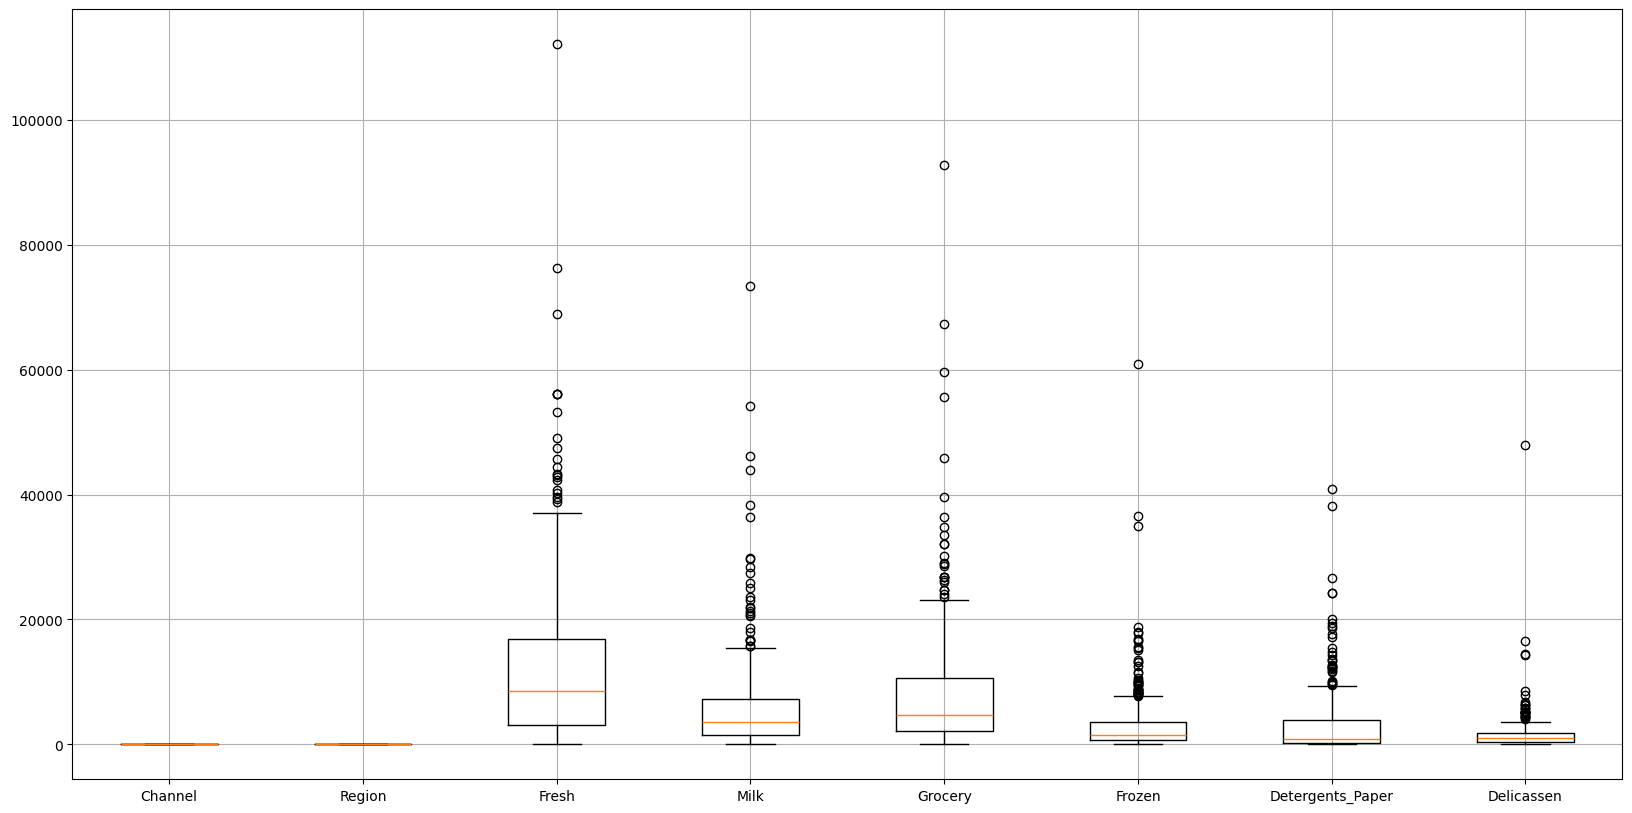

In [44]:
plt.figure(figsize=[20,10])
plt.tight_layout()
plt.grid()
plt.boxplot(df, labels=df.columns)
plt.show()

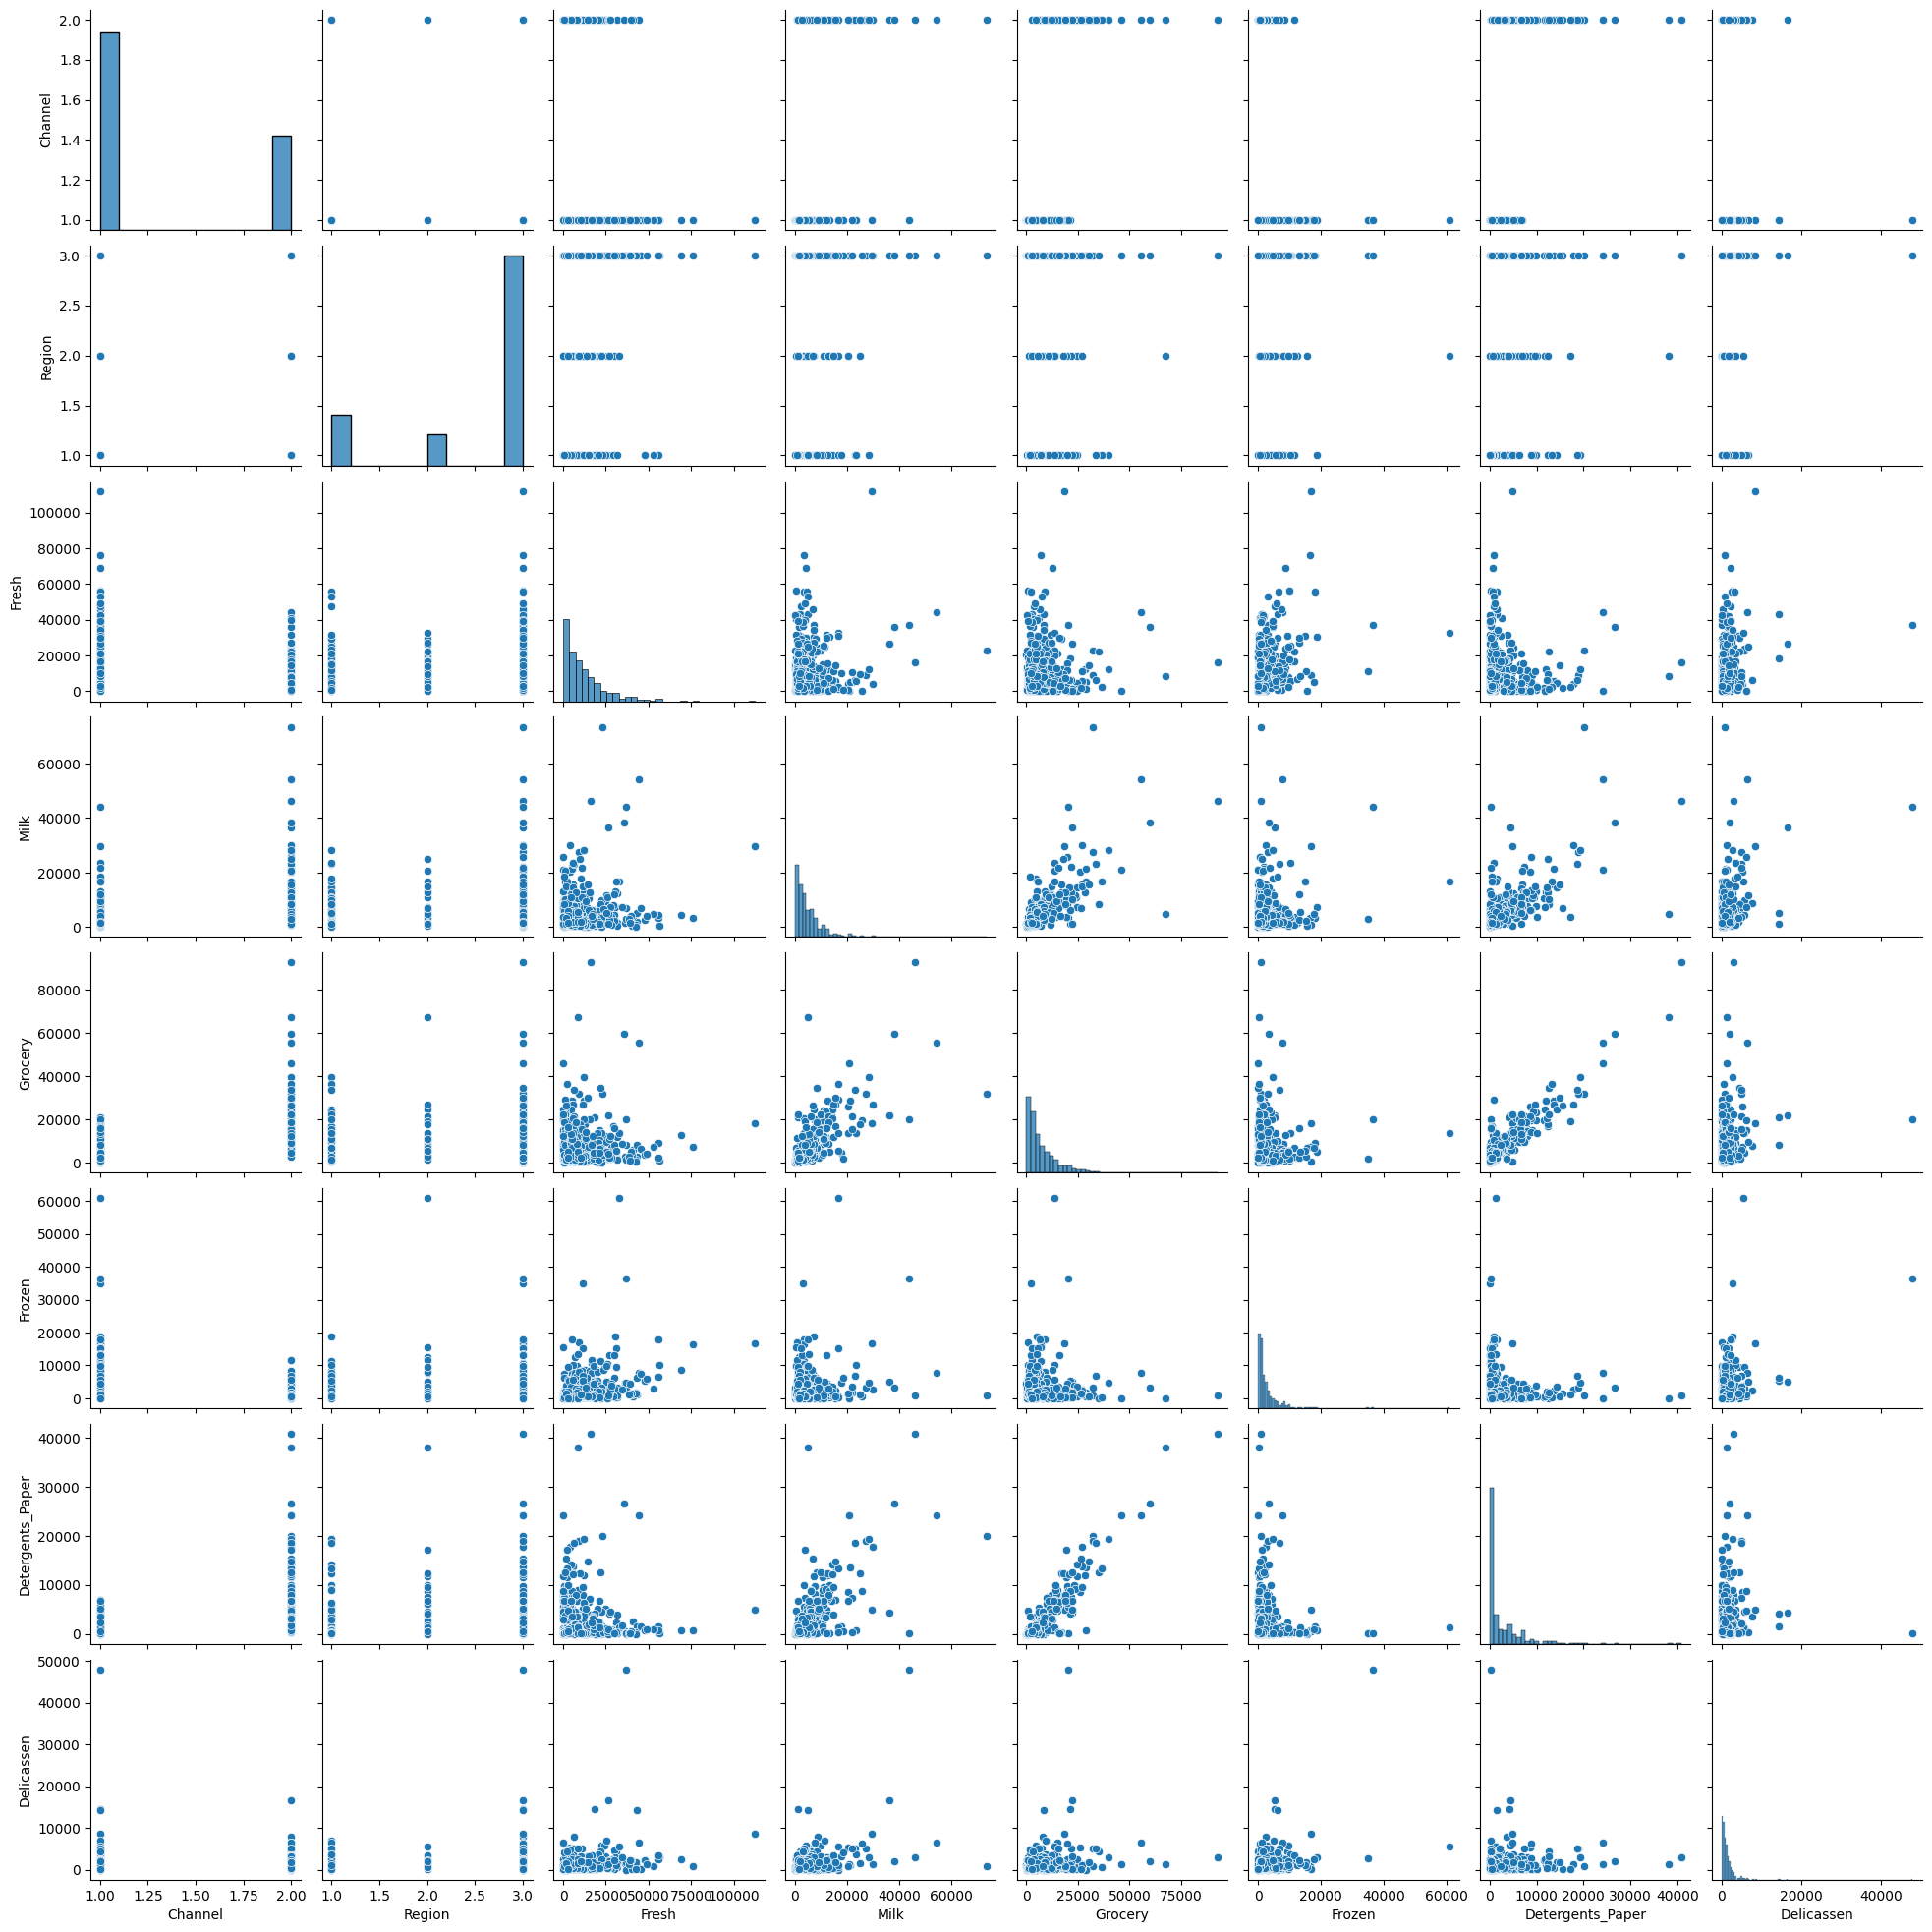

In [45]:
sns.pairplot(df)
plt.show()

We observe that the distributions of values are definitely *skewed*: in the columns from `Fresh` to `Delicassen` the values are highly concentrated on the right, but there are always outliers, frequently in a very large range.

Clustering is more effective in absence of outliers and with all the variables distributed in similar ranges, for this reason, we will execute two transformations:
1. transform all the variables from the column `Fresh` to the column `Delicassen` with [PowerTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html)
1. remap all the variables in the range `0:1`

In [46]:
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import MinMaxScaler

# Save original
df_not_transformed = df.copy()

# 1) 
labels = df.columns[2:]
pt = PowerTransformer()
df[labels] = pt.fit_transform(df[labels])

# 2) 
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)
df = pd.DataFrame(scaled_data, columns=df.columns)

Show the result of the transformation

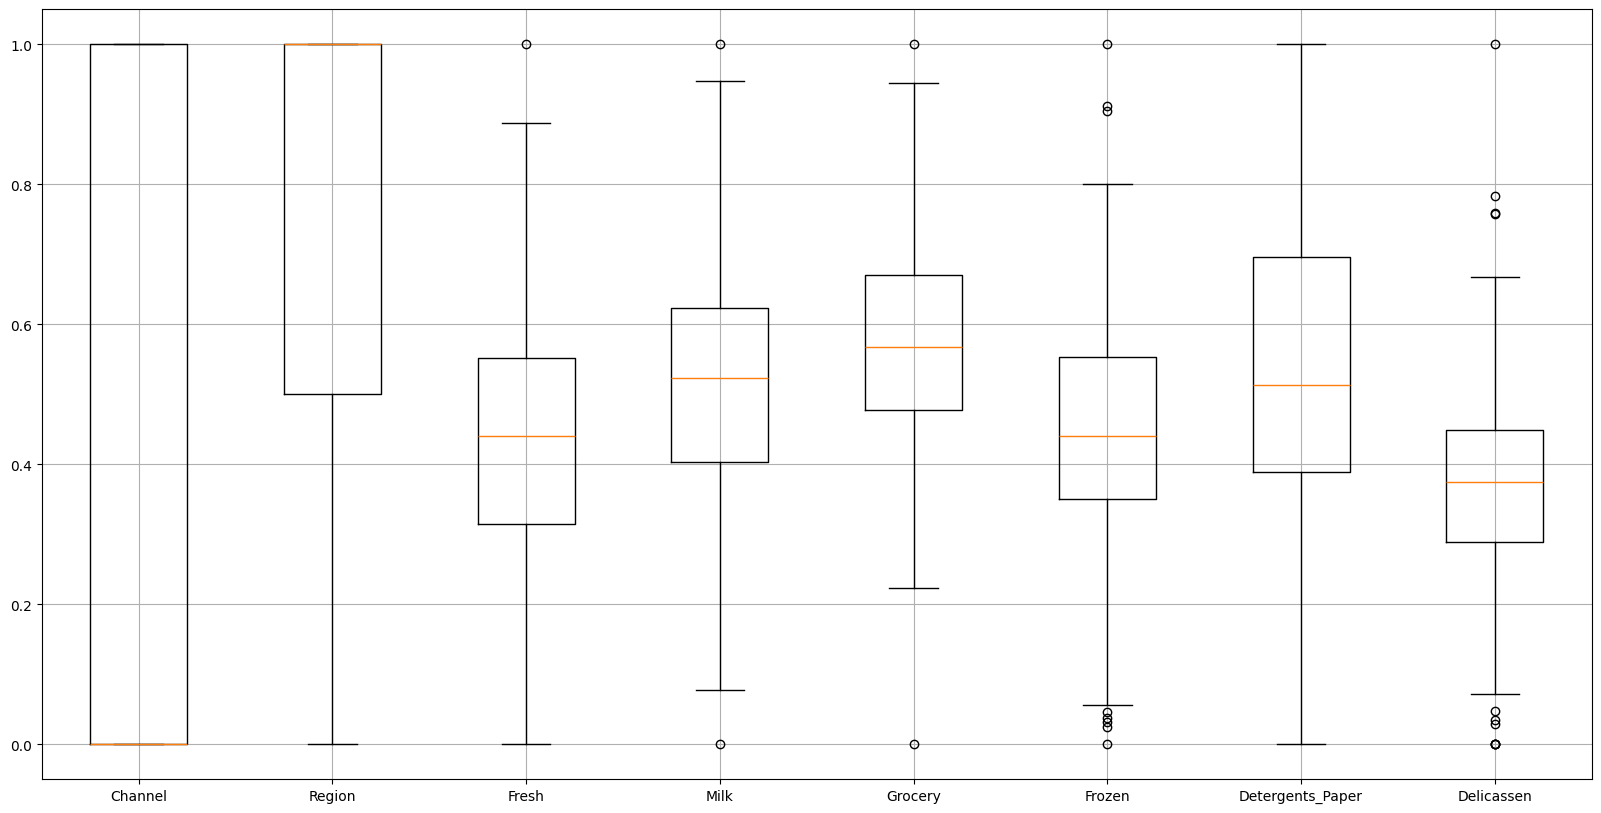

In [47]:
plt.figure(figsize=[20,10])
plt.tight_layout()
plt.grid()
plt.boxplot(df, labels=df.columns)
plt.show()

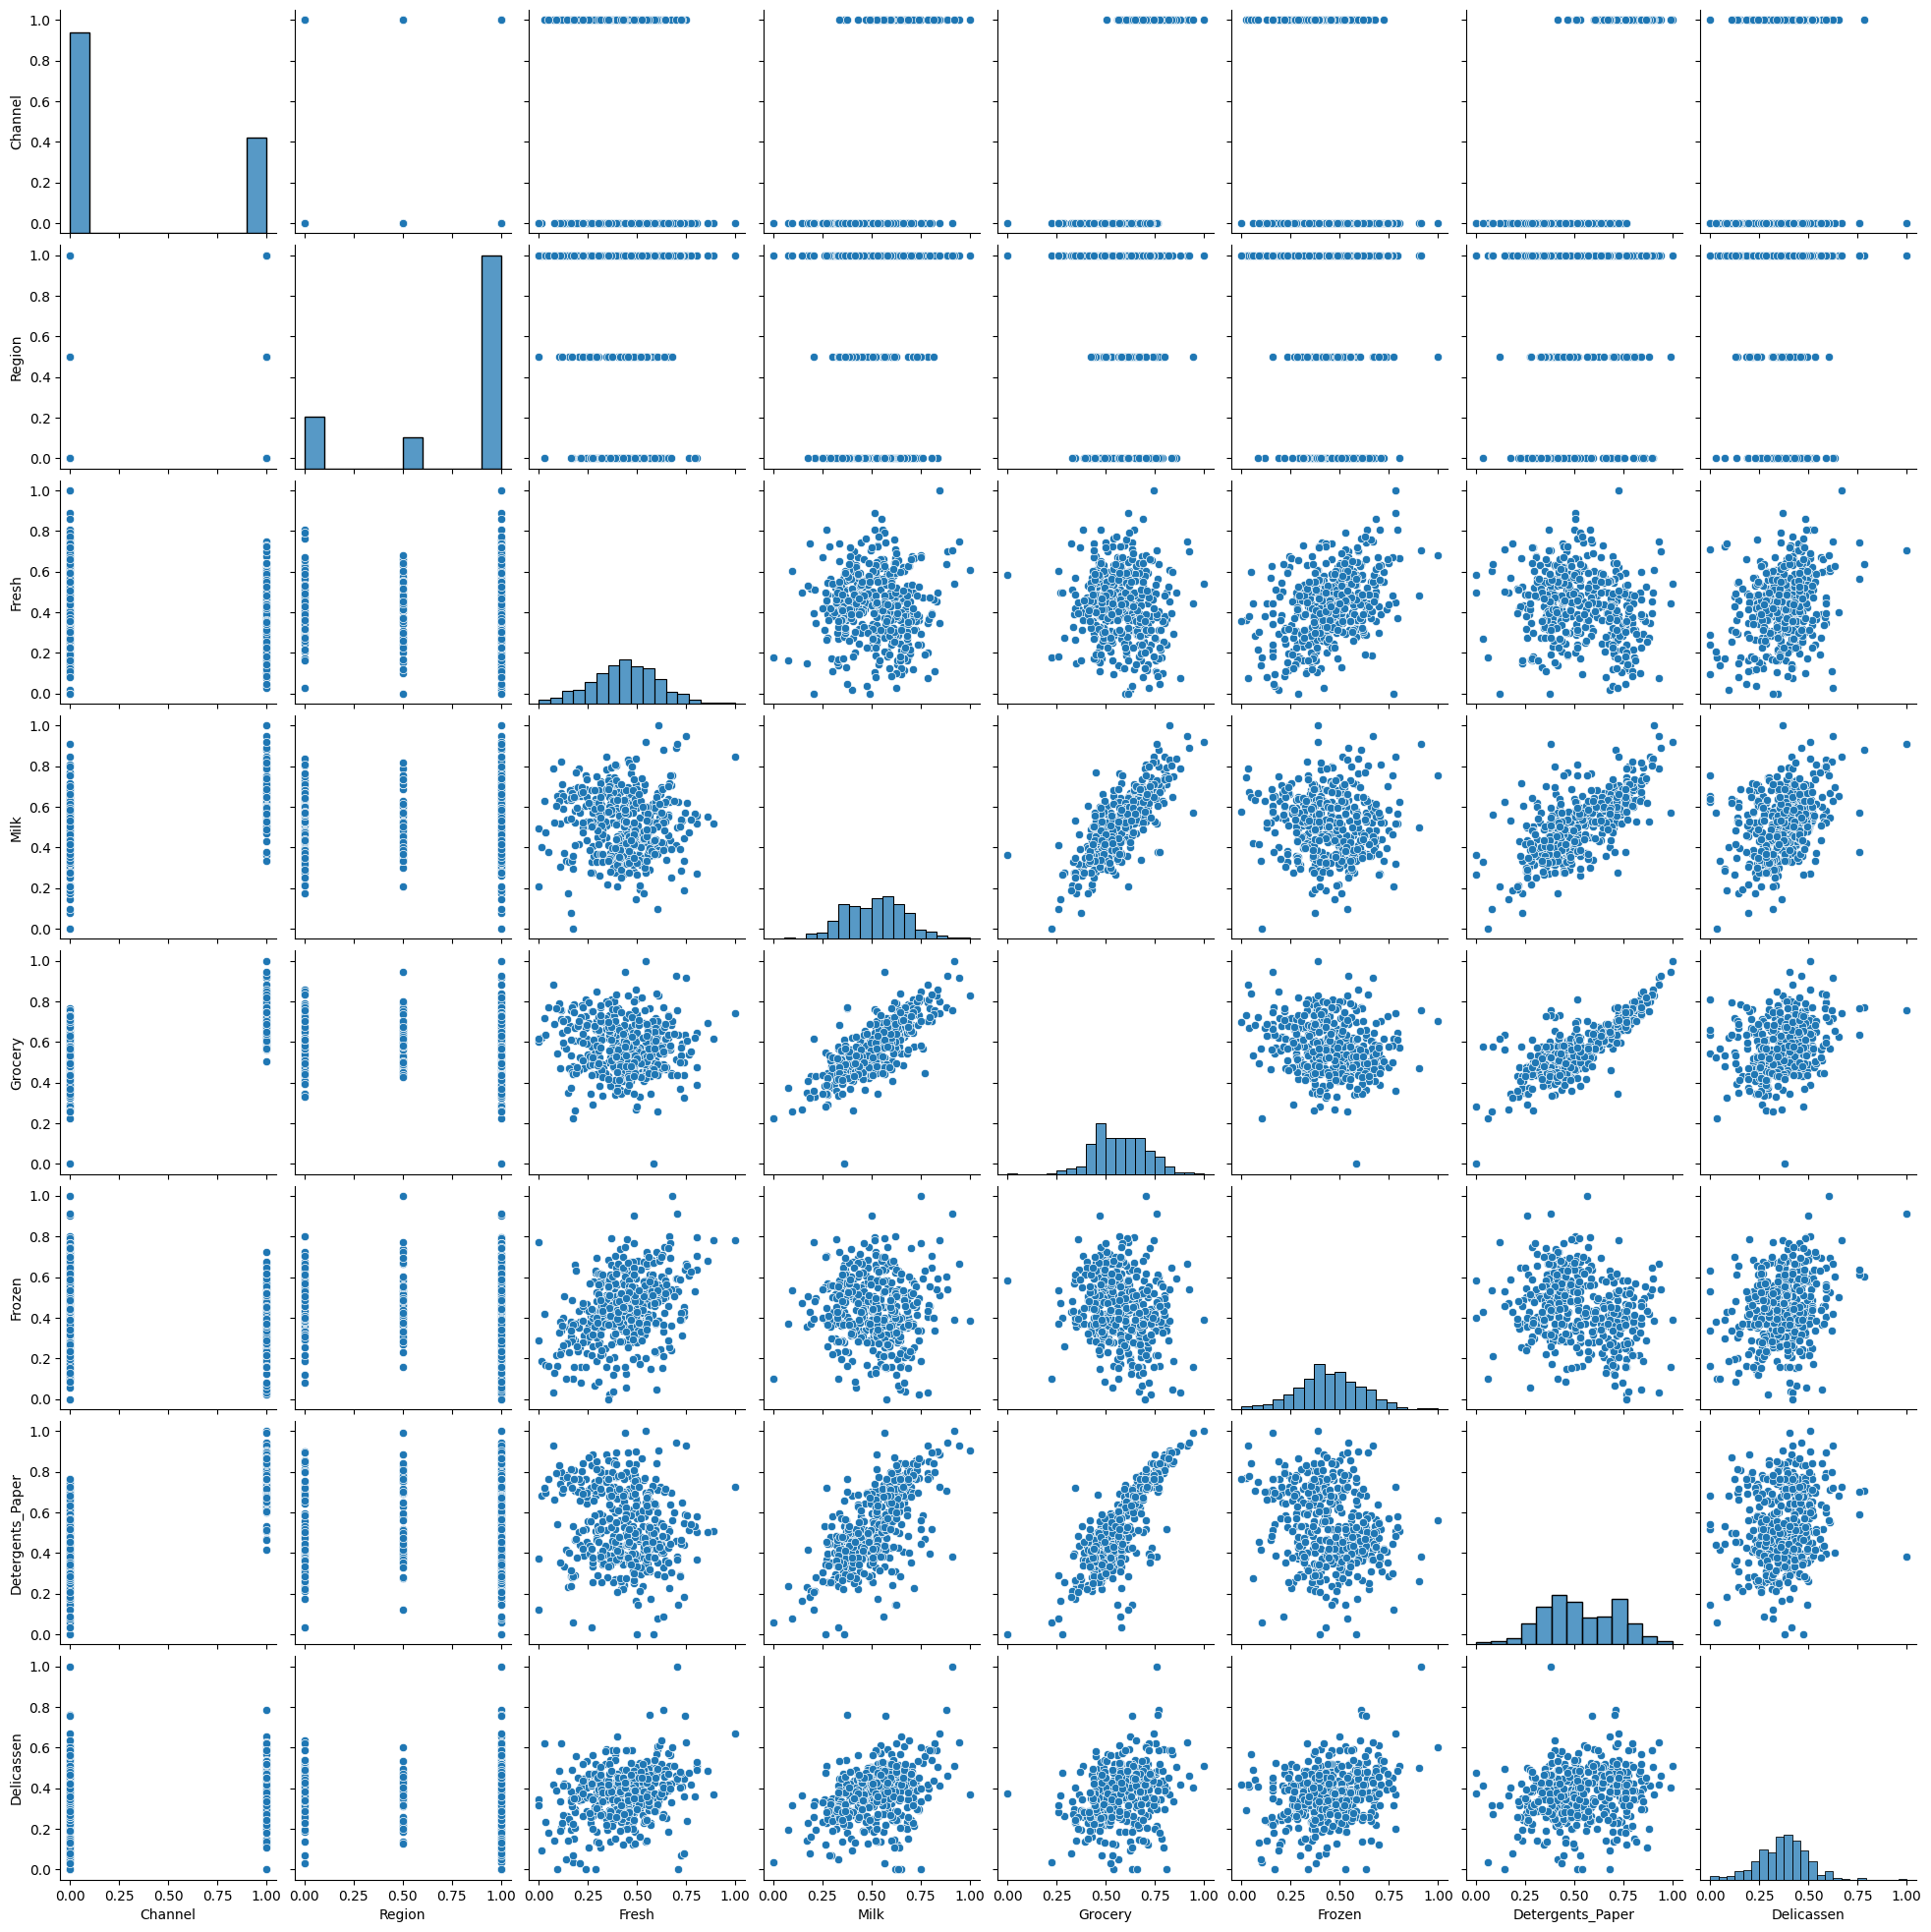

In [48]:
sns.pairplot(df)
plt.show()

Now the effect of outliers is reduced, and we compute the clustering

## 3. Use the elbow method to find the optimal number of clusters
Test `KMeans` with varying number of clusters, from 2 to 10

Prepare the results list that will contain pairs of `inertia` and `silhouette_score` for each value of `k`, then, __for each value__ of `k` 
- initialize an estimator for `KMeans`
- fit the data and predict the cluster assignment for each individual with `fit` and `predict`
- the __inertia__ is provided in the attribute `inertia_` of the fitted model
- compute the __silhouette score__  using the function `silhouette_score` from `sklearn.metrics` using as arguments the data and the fitted labels, we will fill the variable `silhouette_scores`
- store the two values above in the list created at the beginning

In [49]:
inertias = []
silhouette_scores = []
ks = [*range(2,11)]

for k in ks:
    km = KMeans(k, random_state=random_state)
    new_df = km.fit_predict(df)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(df, new_df))

## 4. Plot __inertia__ and __silhouette score__ versus `k`

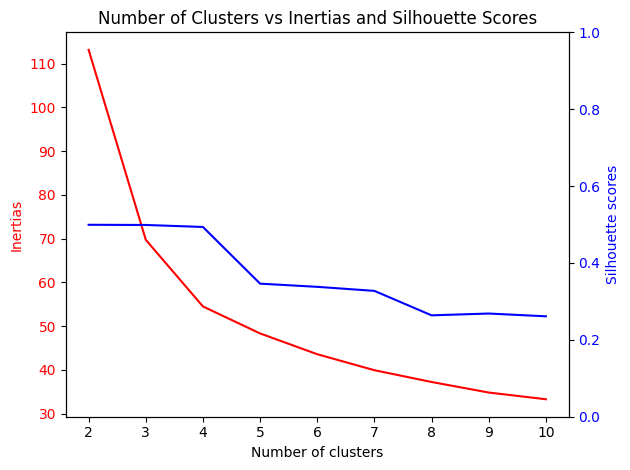

In [50]:
# Crea la figura
fig, ax1 = plt.subplots()

# Plotta le inertie (asse sinistro)
ax1.plot(ks, inertias, 'r-', label="Inertias")
ax1.set_xlabel('Number of clusters')
ax1.set_ylabel('Inertias', color='red')
ax1.tick_params(axis='y', labelcolor='red')

# Aggiungi un secondo asse per i silhouette scores
ax2 = ax1.twinx()
ax2.plot(ks, silhouette_scores, 'b-', label="Silhouette scores")
ax2.set_ylabel('Silhouette scores', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.set_ylim(0,1)

# Mostra il grafico
plt.title('Number of Clusters vs Inertias and Silhouette Scores')
plt.tight_layout()
plt.show()

## 5. Cluster with the optimal number
The two *elbow* points of inertia would suggest as cluster number 3 or 4, slightly more pronounced in 3. Silhouette has a maximum on 4, but the increase with respect to 3 is very small.

We will choose k=4

In [51]:
k = 4
print(f"Number of clusters = {k}")
print(f"Distortion = {round(inertias[ks.index(k)],2)}")
print(f"Silhouette score = {round(silhouette_scores[ks.index(k)],2)}")

km = KMeans(k, random_state=random_state)
new_df = km.fit_predict(df)

Number of clusters = 4
Distortion = 54.49
Silhouette score = 0.49


Show the distribution of samples in the clusters with a pie chart

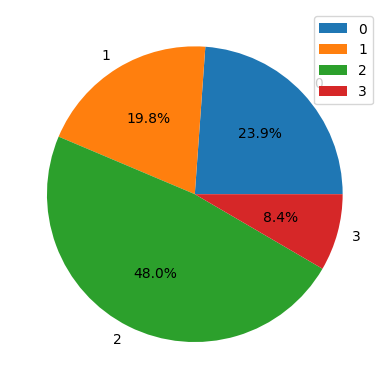

In [52]:
vals, freqs = np.unique(new_df, return_counts=True)
plt.pie(x=freqs, labels=vals, autopct='%1.1f%%')    # 1.X where X is the num of decimals
plt.legend()
plt.show()

### Comments
The __silhouette score__ ranges from `-1` (worst) to `1` (best); as a rule of thumb, a value greater than `0.5` should be considered acceptable.

## Agglomerative clustering
We will try a grid of parameter configurations, with the number of clusters in the range `2:10` and the four linkage methods available in the *sklearn* implementation of *AgglomerativeClustering*. 

In [53]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.model_selection import GridSearchCV

ks = [*range(2,11)]
methods = ["ward", "complete", "single", "average"]
# clustering = AgglomerativeClustering().fit(df)

In [54]:
n_cluster = []
linkages = []
silhouette_scores = []

for method in methods:
    for k in ks:
        clustering = AgglomerativeClustering(n_clusters=k, linkage=method)
        n_cluster.append(k)
        linkages.append(method)
        silhouette_scores.append(silhouette_score(df, clustering.fit_predict(df)))

results = pd.DataFrame({
    "linkage" : linkages,
    "n_clusters" : n_cluster,
    "silhouette_score" : silhouette_scores
})

In [55]:
results.sort_values(by="silhouette_score", ascending=False)

,linkage,n_clusters,silhouette_score
0,ward,2,0.499350
27,average,2,0.499350
18,single,2,0.499350
9,complete,2,0.499350
1,ward,3,0.498333
2,ward,4,0.493085
29,average,4,0.479507
11,complete,4,0.479507
30,average,5,0.475050
31,average,6,0.443867


The top five results have a very similar silhouette score, we will choose the setting with 4 clusters, as for k-means, and the linkage giving the best result with 4 clusters, that is `ward`. This is the result record with `index 2` (the record index is the unnamed column at the very left of the dataframe output

In [56]:
best = results[results.index==2]
best

,linkage,n_clusters,silhouette_score
2,ward,4,0.493085


In [57]:
clustering = AgglomerativeClustering(n_clusters=best["n_clusters"].values[0], linkage=best["linkage"].values[0])
new_df_ac = clustering.fit_predict(df)

km = KMeans(n_clusters=best["n_clusters"].values[0], random_state=random_state)
new_df_km = km.fit_predict(df)

Show the distribution of data in the clusters

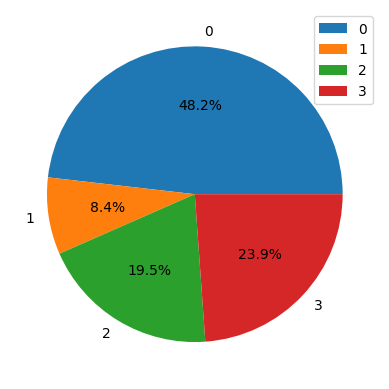

In [58]:
vals, freqs = np.unique(new_df_ac, return_counts=True)
plt.pie(x=freqs, labels=vals, autopct='%1.1f%%')    # 1.X where X is the num of decimals
plt.legend()
plt.show()

In [59]:
df_not_transformed["cluster_ac"] = new_df_ac
df_not_transformed["cluster_km"] = new_df_km

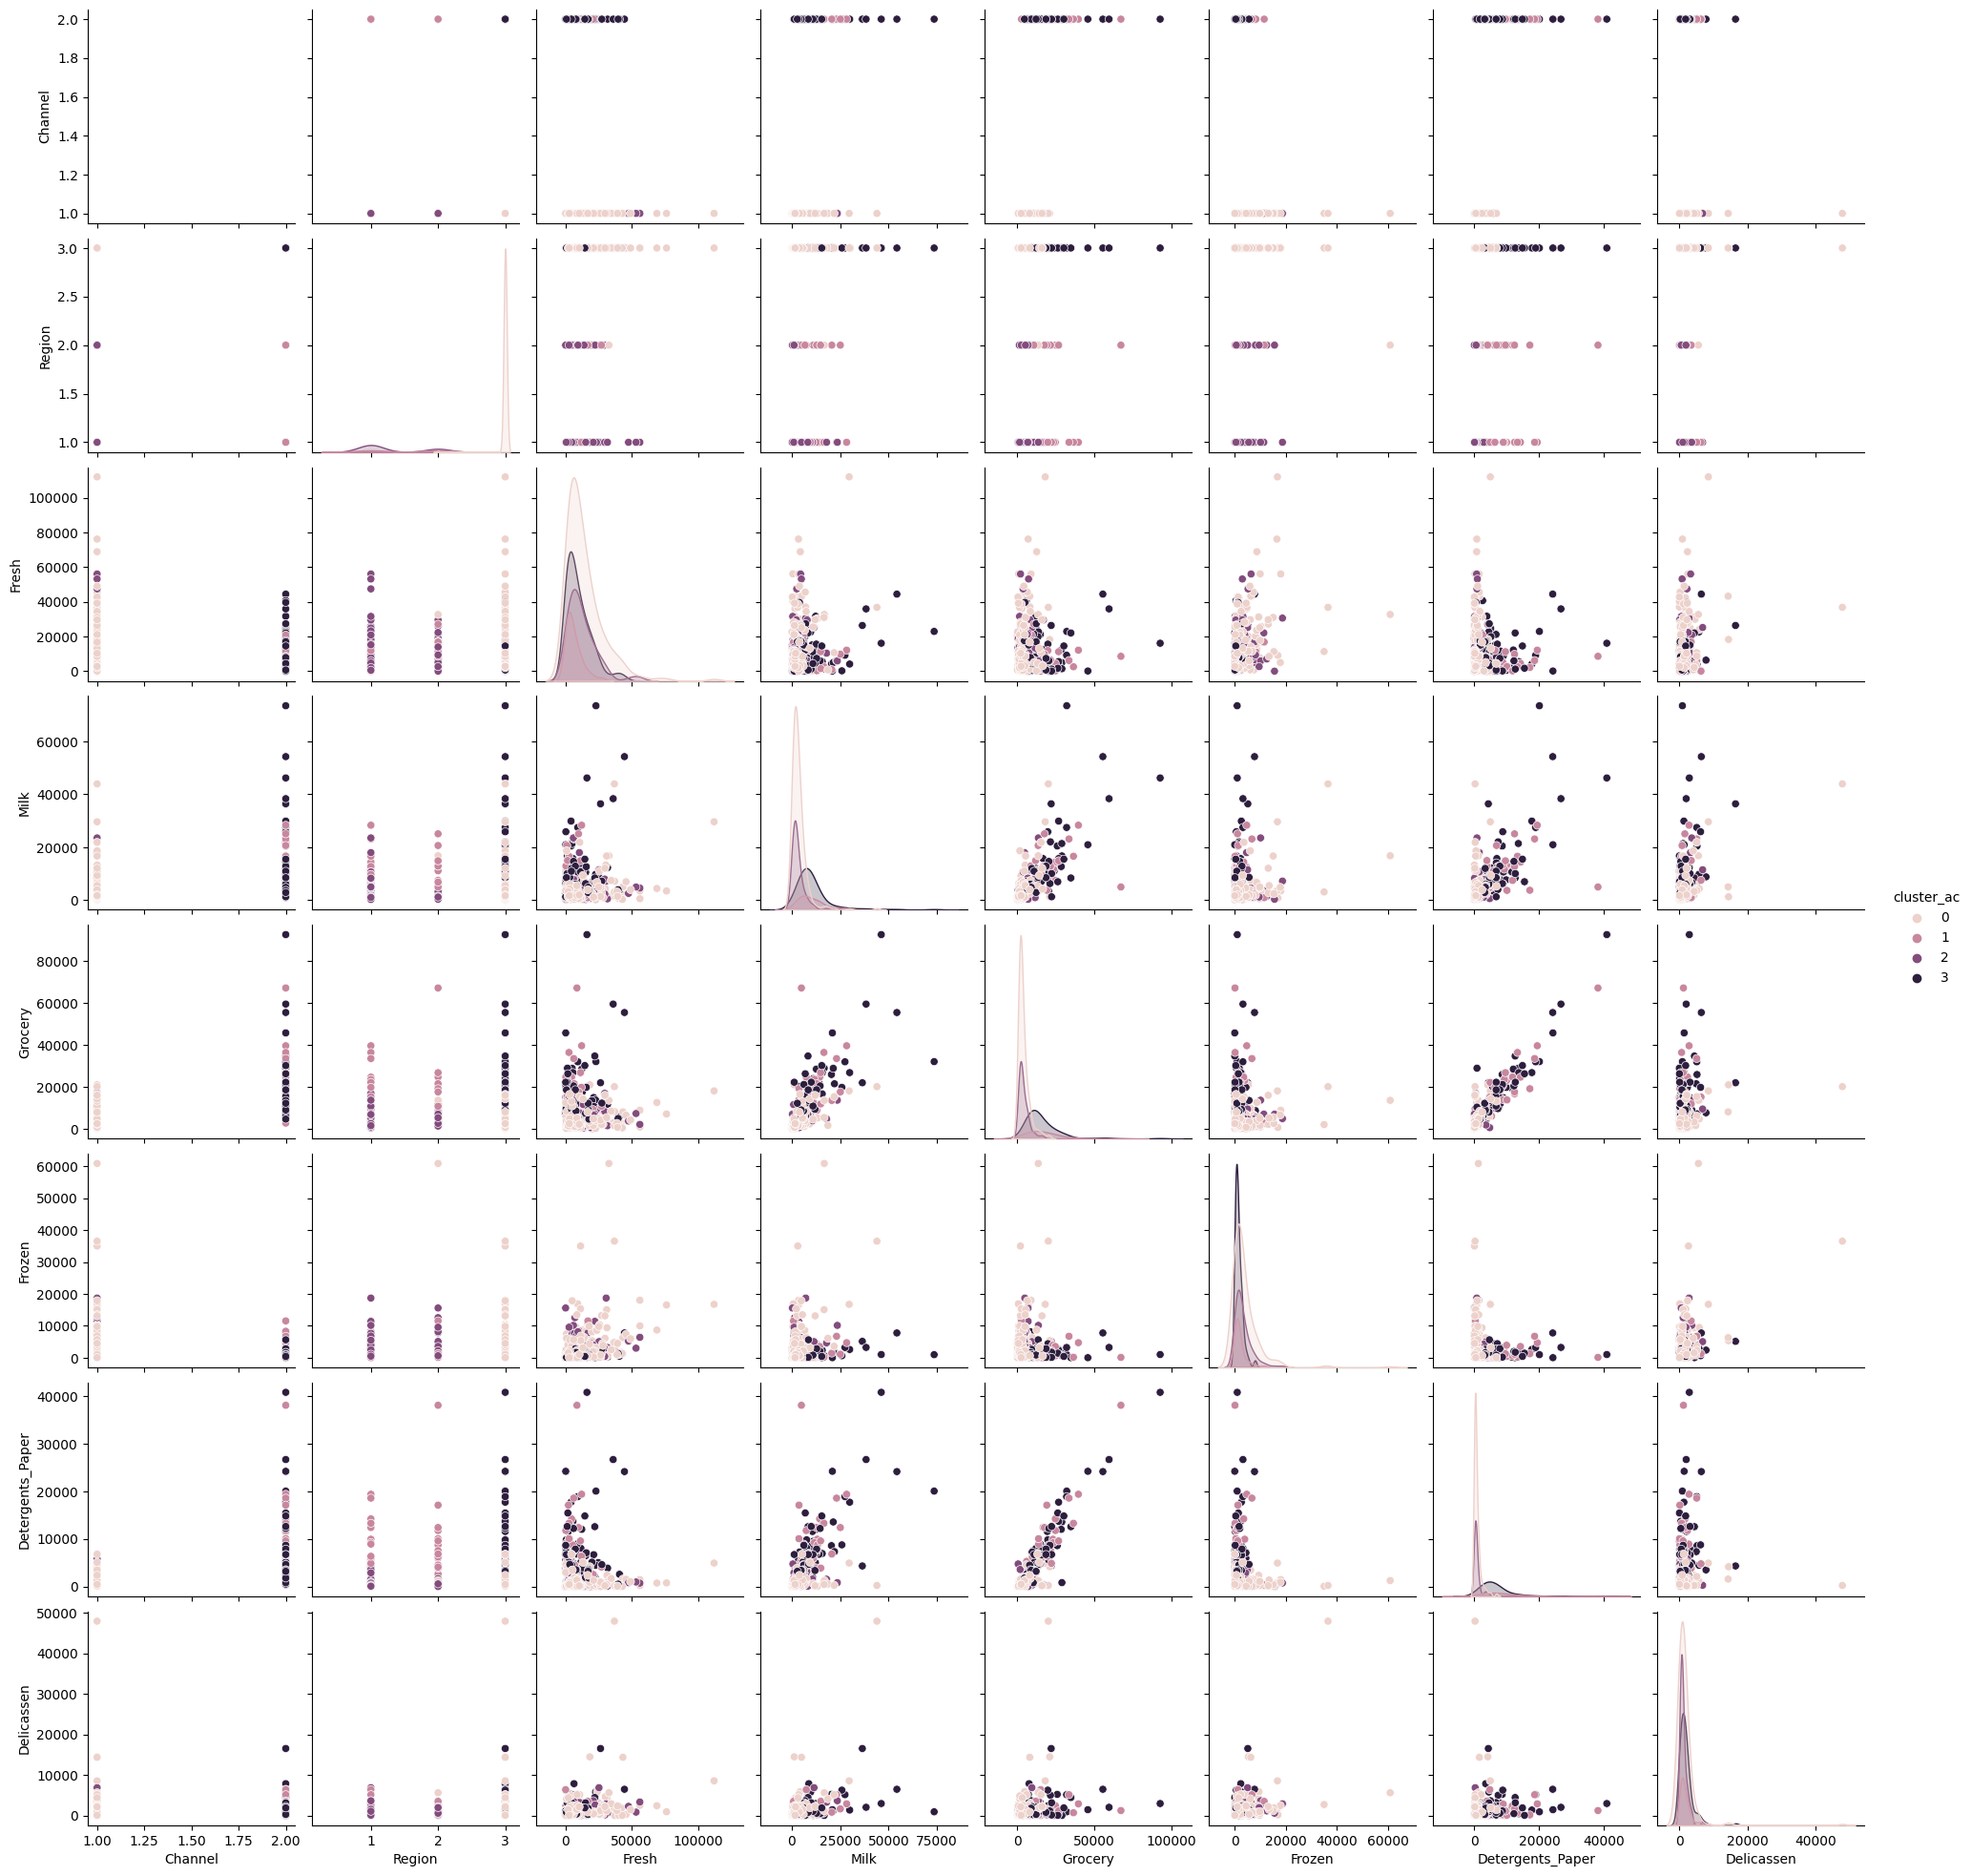

In [ ]:
sns.pairplot(df_not_transformed.drop(["cluster_km"], axis=1), diag_kind="kde", hue="cluster_ac")
plt.show()

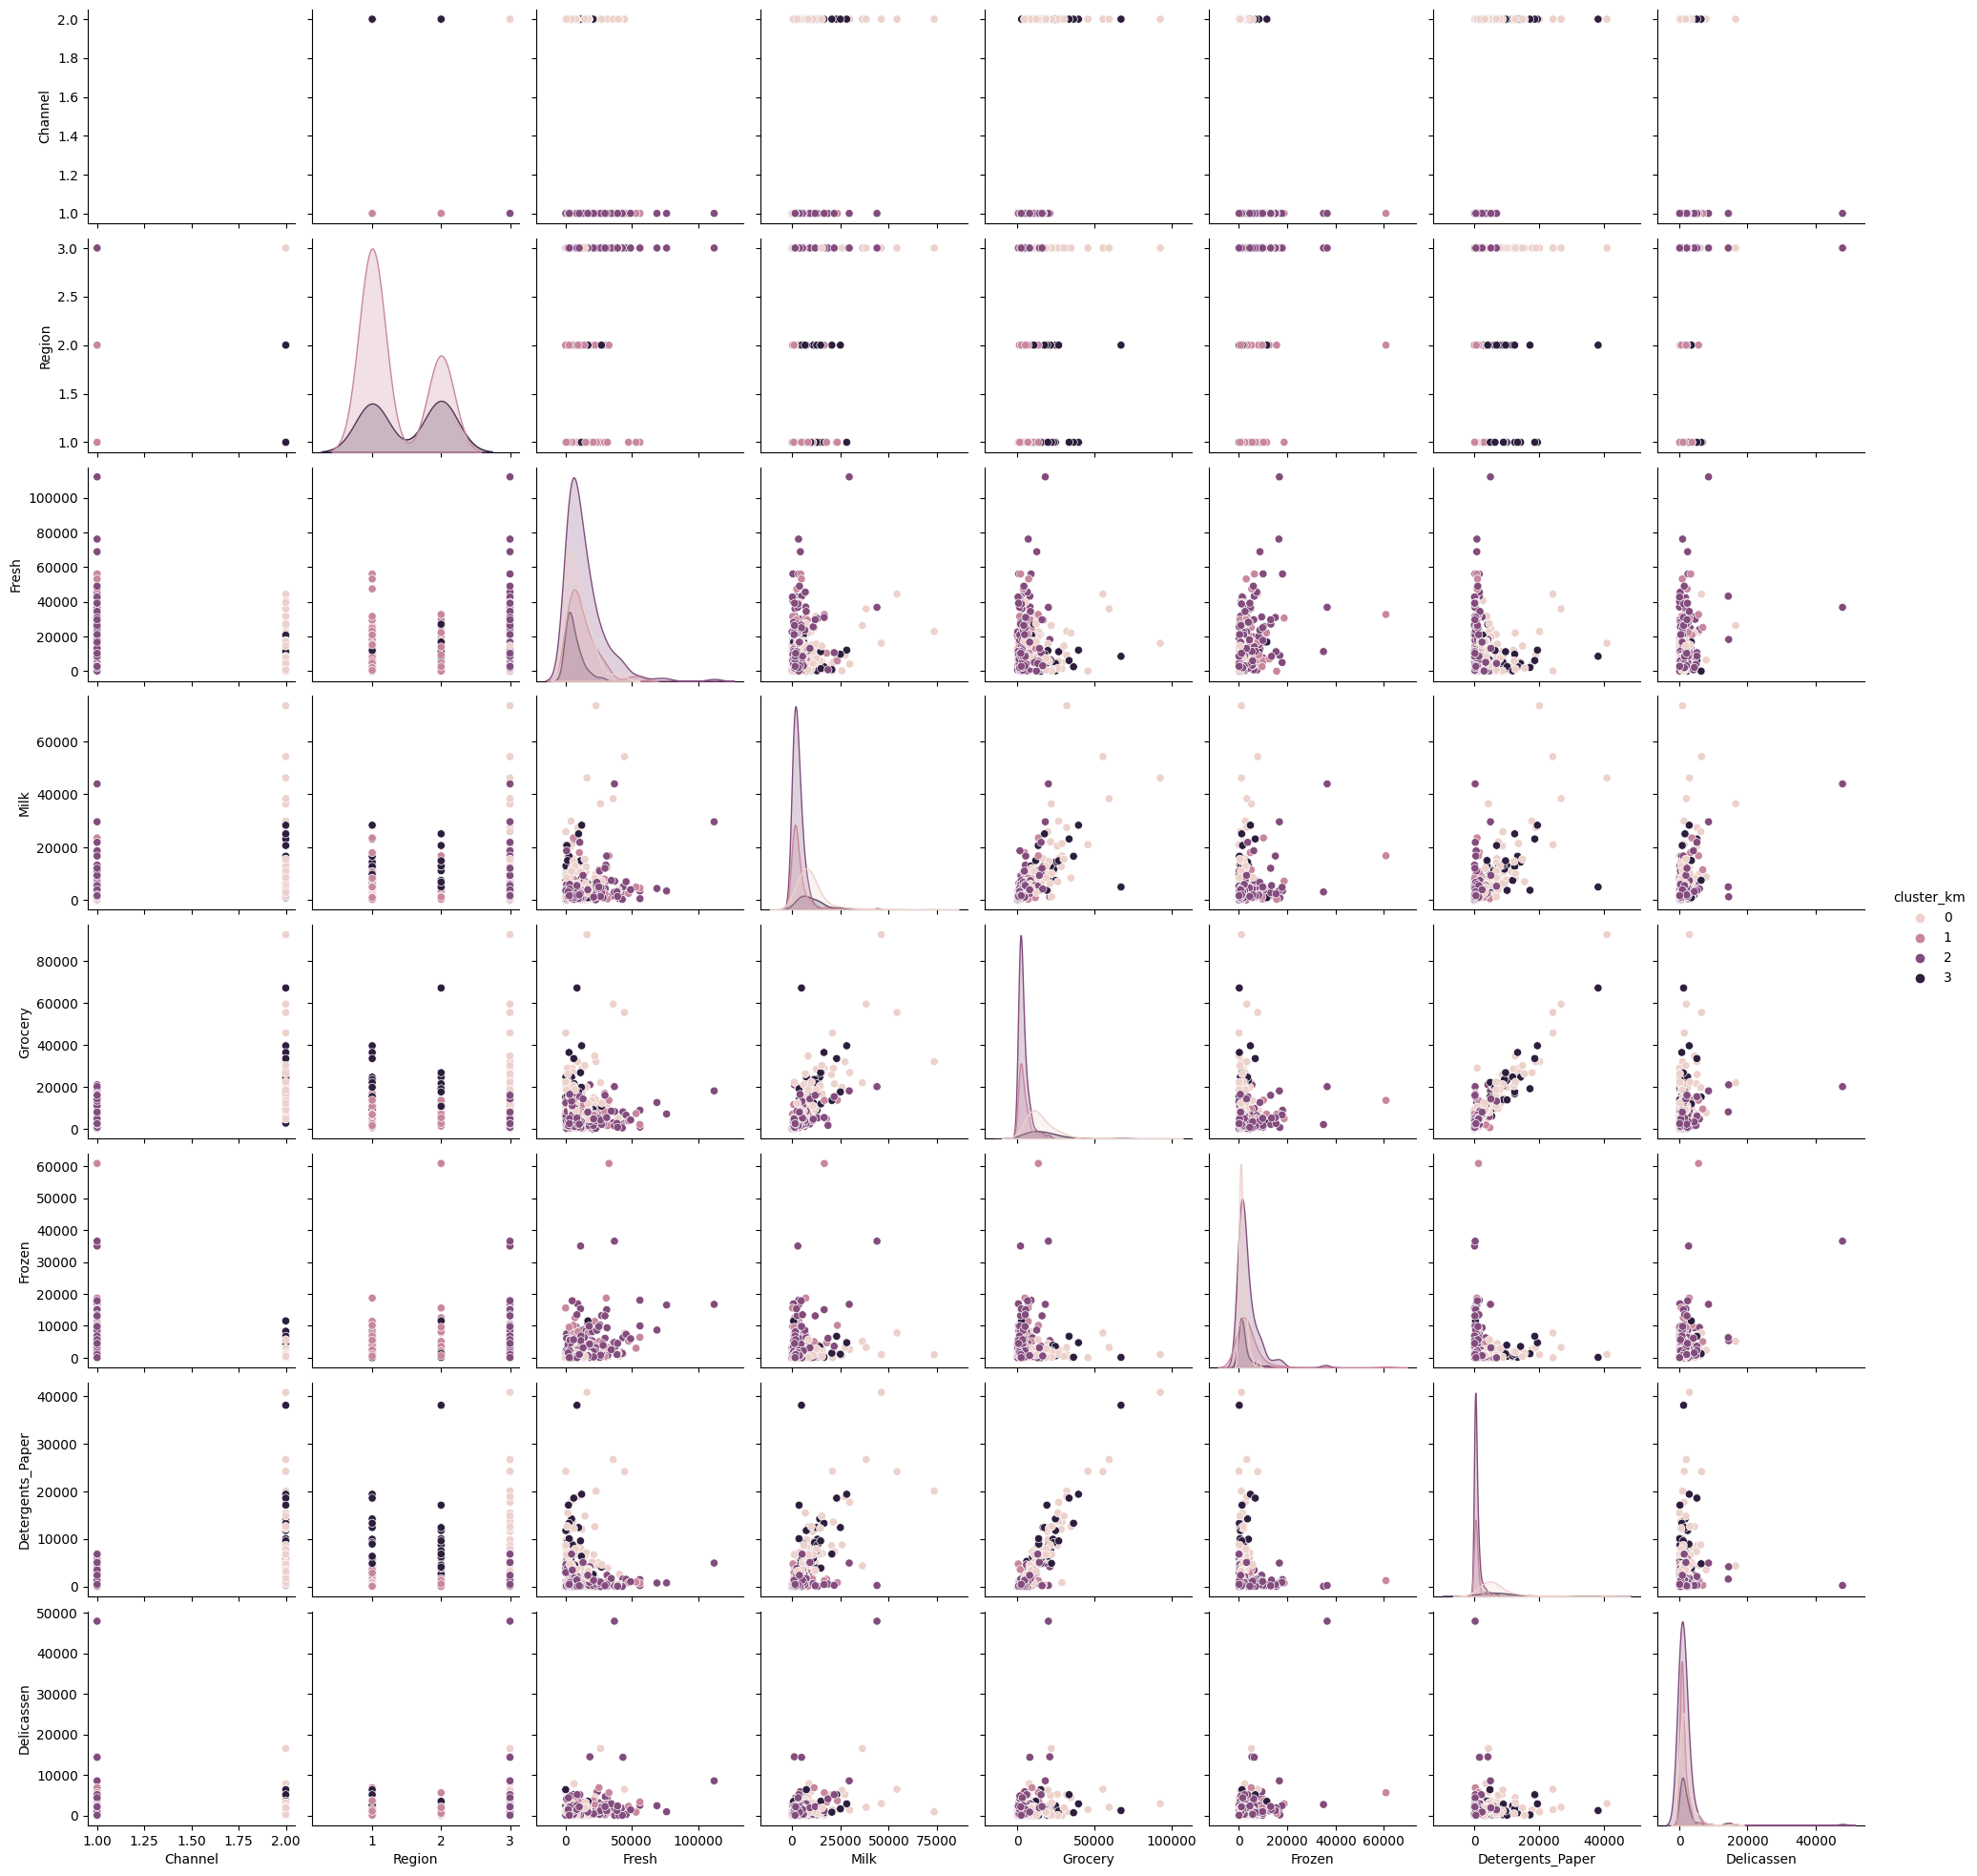

In [61]:
sns.pairplot(df_not_transformed.drop(["cluster_ac"], axis=1), diag_kind="kde", hue="cluster_km")
plt.show()

### Comments


The solution with the Agglomerative Clustering in this case provides a result very similar to that of kmeans.

It is interesting to compare more deeply the results of the two clustering models. 

The function `pair_confusion_matrix` computes the number of pairs of objects that are in the same clusters or in different clusters in two different clustering schemes. 

The result is given in a 2x2 matrix, the smaller the numbers out of the main diagona, the better the match.

For easier readability, we divide all the elements of the matrix by the sum of all the elements of the matrix, in this way, the matrix elements are normalized to 1.

In [73]:
from sklearn.metrics import pair_confusion_matrix
cm = pair_confusion_matrix(new_df_ac, new_df_km)
# cm_normalized = np.array([[cm[i][j]/np.sum(cm) for i in range(cm.shape[0])] for j in range(cm.shape[1])])
cm_normalized = cm / np.sum(cm)

A short indicator of the match percentage can be optained as a sum of the elements of the main diagonal.

In [76]:
cm_normalized

array([[0.66625595, 0.00089045],
       [0.00218472, 0.33066888]])

In [75]:
print(f"The percentage of matches is {round(np.sum(cm_normalized.diagonal())*100, 2)}")

The percentage of matches is 99.69


## DBSCAN

In [87]:
from sklearn.cluster import DBSCAN
dbs = DBSCAN()

In [ ]:
def_params = dbs.get_params()
eps = def_params["eps"]
min_samples = def_params["min_samples"]
print(f"Defauld parameters - Eps={eps} - Min_samples={min_samples}")

Defauld parameters - Eps=0.5 - Min_samples=5


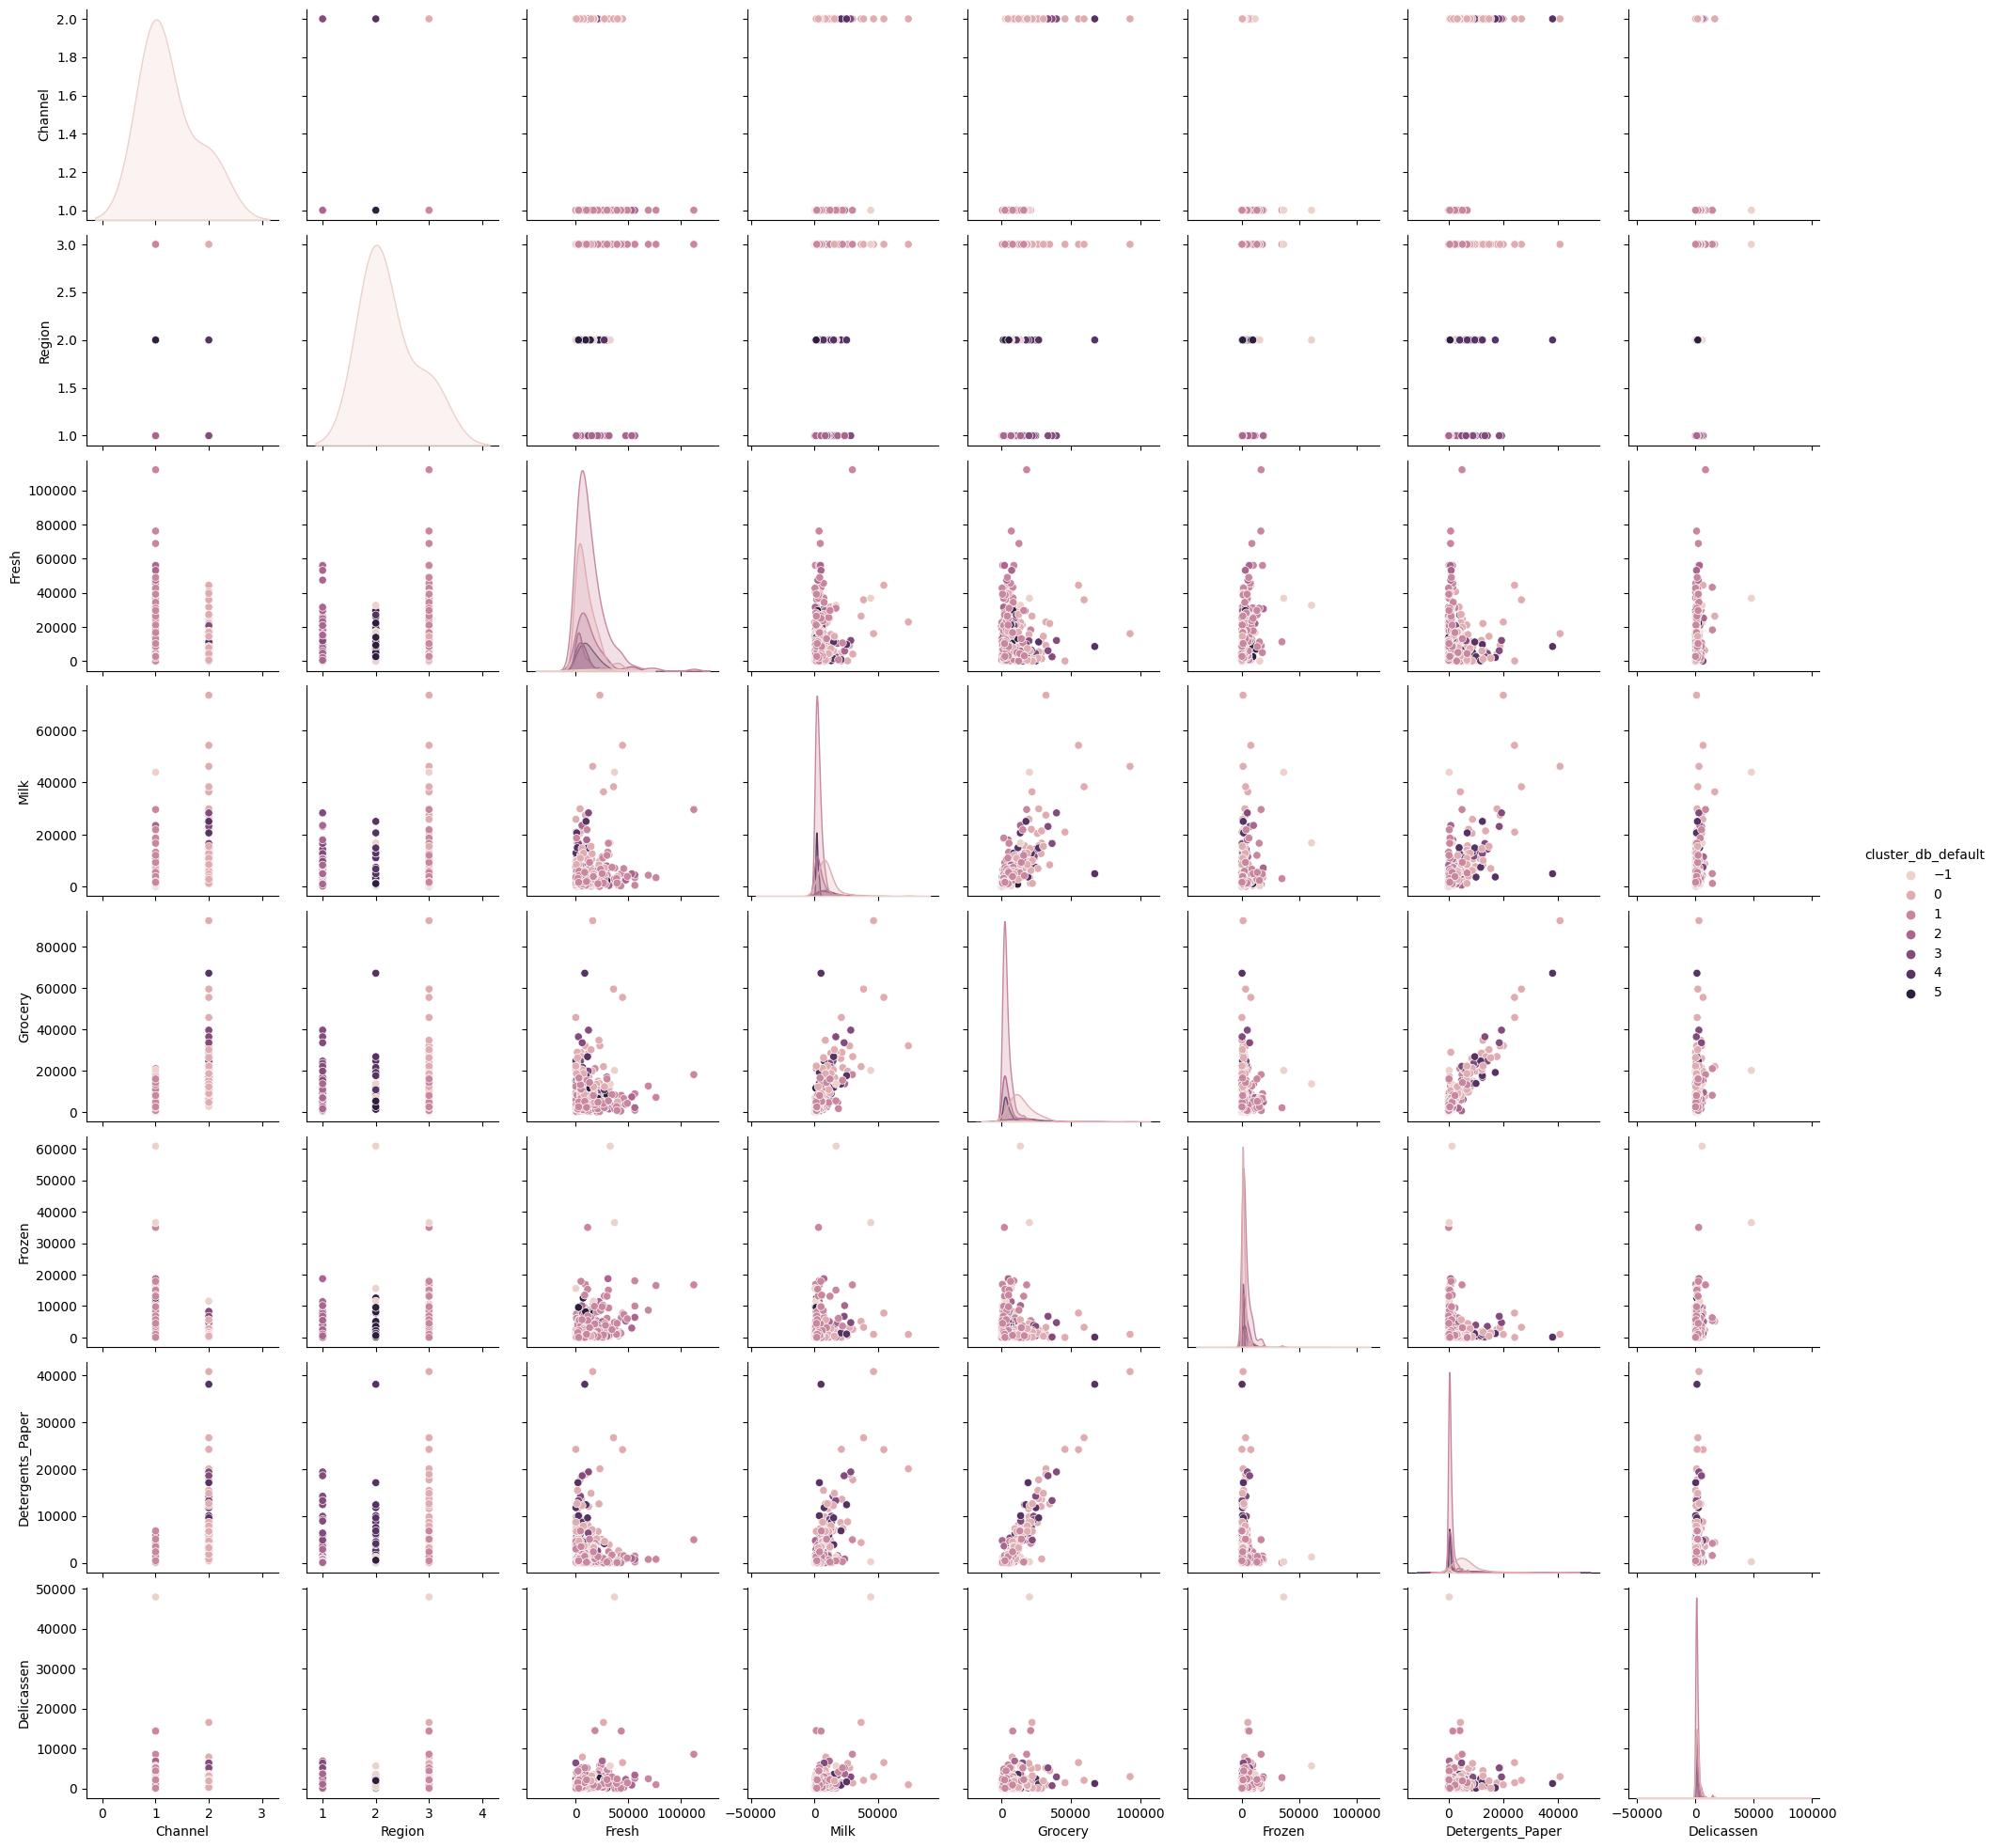

In [89]:
df_not_transformed["cluster_db_default"] = dbs.fit_predict(df)
sns.pairplot(df_not_transformed.drop(["cluster_km", "cluster_ac"], axis=1), diag_kind="kde", hue="cluster_db_default")
plt.show()

Show the distribution of data in the clusters

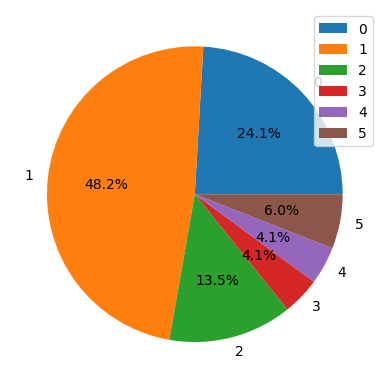

In [ ]:
vals, freqs = np.unique(df_not_transformed["cluster_db_default"], return_counts=True)
plt.pie(x=freqs[1:], labels=vals[1:], autopct='%1.1f%%')    # 1.X where X is the num of decimals
plt.legend()
plt.show()

### 5. Find the best parameters using `ParameterGrid`

prepare the dictionary of the parameter ranges and produce the list of parameter settings to test with the function `ParameterGrid`

In [107]:
dict_params = {
    "min_samples" : [*range(2,10)],
    "eps" : np.arange(0.001,1.001,step=0.001)
}

Arrange DBSCAN results in a dataframe, for easier presentation and filtering

`dbscan_out = pd.DataFrame(columns =  ['eps','min_samples','n_clusters','silhouette', 'unclust%'])`

- for each parameter setting

In [147]:
dbscan_out = pd.DataFrame(columns = ['eps','min_samples','n_clusters','silhouette', 'unclust%'])

In [148]:
pg = ParameterGrid(dict_params)
for cfg in pg:
    dbs = DBSCAN(**cfg)
    new_df = dbs.fit_predict(df)
    
    clustered_points = df[new_df != -1]
    clustered_labels = new_df[new_df != -1]
    
    if len(np.unique(clustered_labels)) > 1:  # silhouette_score richiede almeno 2 cluster
        s_score = silhouette_score(clustered_points, clustered_labels)
    
    unclustered = np.sum(new_df == -1)/len(new_df)  # Numero di punti non clusterizzati %
    n_clusters = len(np.unique(clustered_labels))  # Numero di cluster
    
    if n_clusters>1:
        dbscan_out.loc[len(dbscan_out)] = [
            cfg["eps"],
            cfg["min_samples"],
            n_clusters,
            s_score,
            unclustered
        ]

In [149]:
dbscan_out

,eps,min_samples,n_clusters,silhouette,unclust%
0,0.047,2.0,2.0,0.966331,0.990909
1,0.048,2.0,3.0,0.862396,0.986364
2,0.049,2.0,3.0,0.862396,0.986364
3,0.050,2.0,3.0,0.862396,0.986364
4,0.051,2.0,4.0,0.809127,0.981818
...,...,...,...,...,...
7236,1.000,5.0,2.0,0.499350,0.000000
7237,1.000,6.0,2.0,0.499350,0.000000
7238,1.000,7.0,2.0,0.499350,0.000000
7239,1.000,8.0,2.0,0.499350,0.000000


In [173]:
dbscan_out_sorted = dbscan_out.sort_values(by="silhouette", ascending=False)
dbs_sorted_filtered = dbscan_out_sorted[  
    (dbscan_out_sorted["n_clusters"]==4.0) & \
    (dbscan_out_sorted["unclust%"]<=0.30)
]
dbs_sorted_filtered

,eps,min_samples,n_clusters,silhouette,unclust%
3296,0.507,9.0,4.0,0.529010,0.009091
3280,0.505,9.0,4.0,0.529010,0.009091
3273,0.505,2.0,4.0,0.529010,0.009091
3274,0.505,3.0,4.0,0.529010,0.009091
3275,0.505,4.0,4.0,0.529010,0.009091
3279,0.505,8.0,4.0,0.529010,0.009091
3295,0.507,8.0,4.0,0.529010,0.009091
3294,0.507,7.0,4.0,0.529010,0.009091
3293,0.507,6.0,4.0,0.529010,0.009091
3292,0.507,5.0,4.0,0.529010,0.009091


### 6. Observe  
- Observe visually the most promising combination of parameters reproducing the same number of clusters of the previous experiments 
- fit and predict the cluster labels and show a pairplot

In [174]:
best_dbs = dbs_sorted_filtered.iloc[0, :]
dbs = DBSCAN(eps=best_dbs["eps"], min_samples=int(best_dbs["min_samples"]))
new_df_best_dbs = dbs.fit_predict(df)

In [175]:
df_not_transformed["cluster_dbs_best"] = new_df_best_dbs

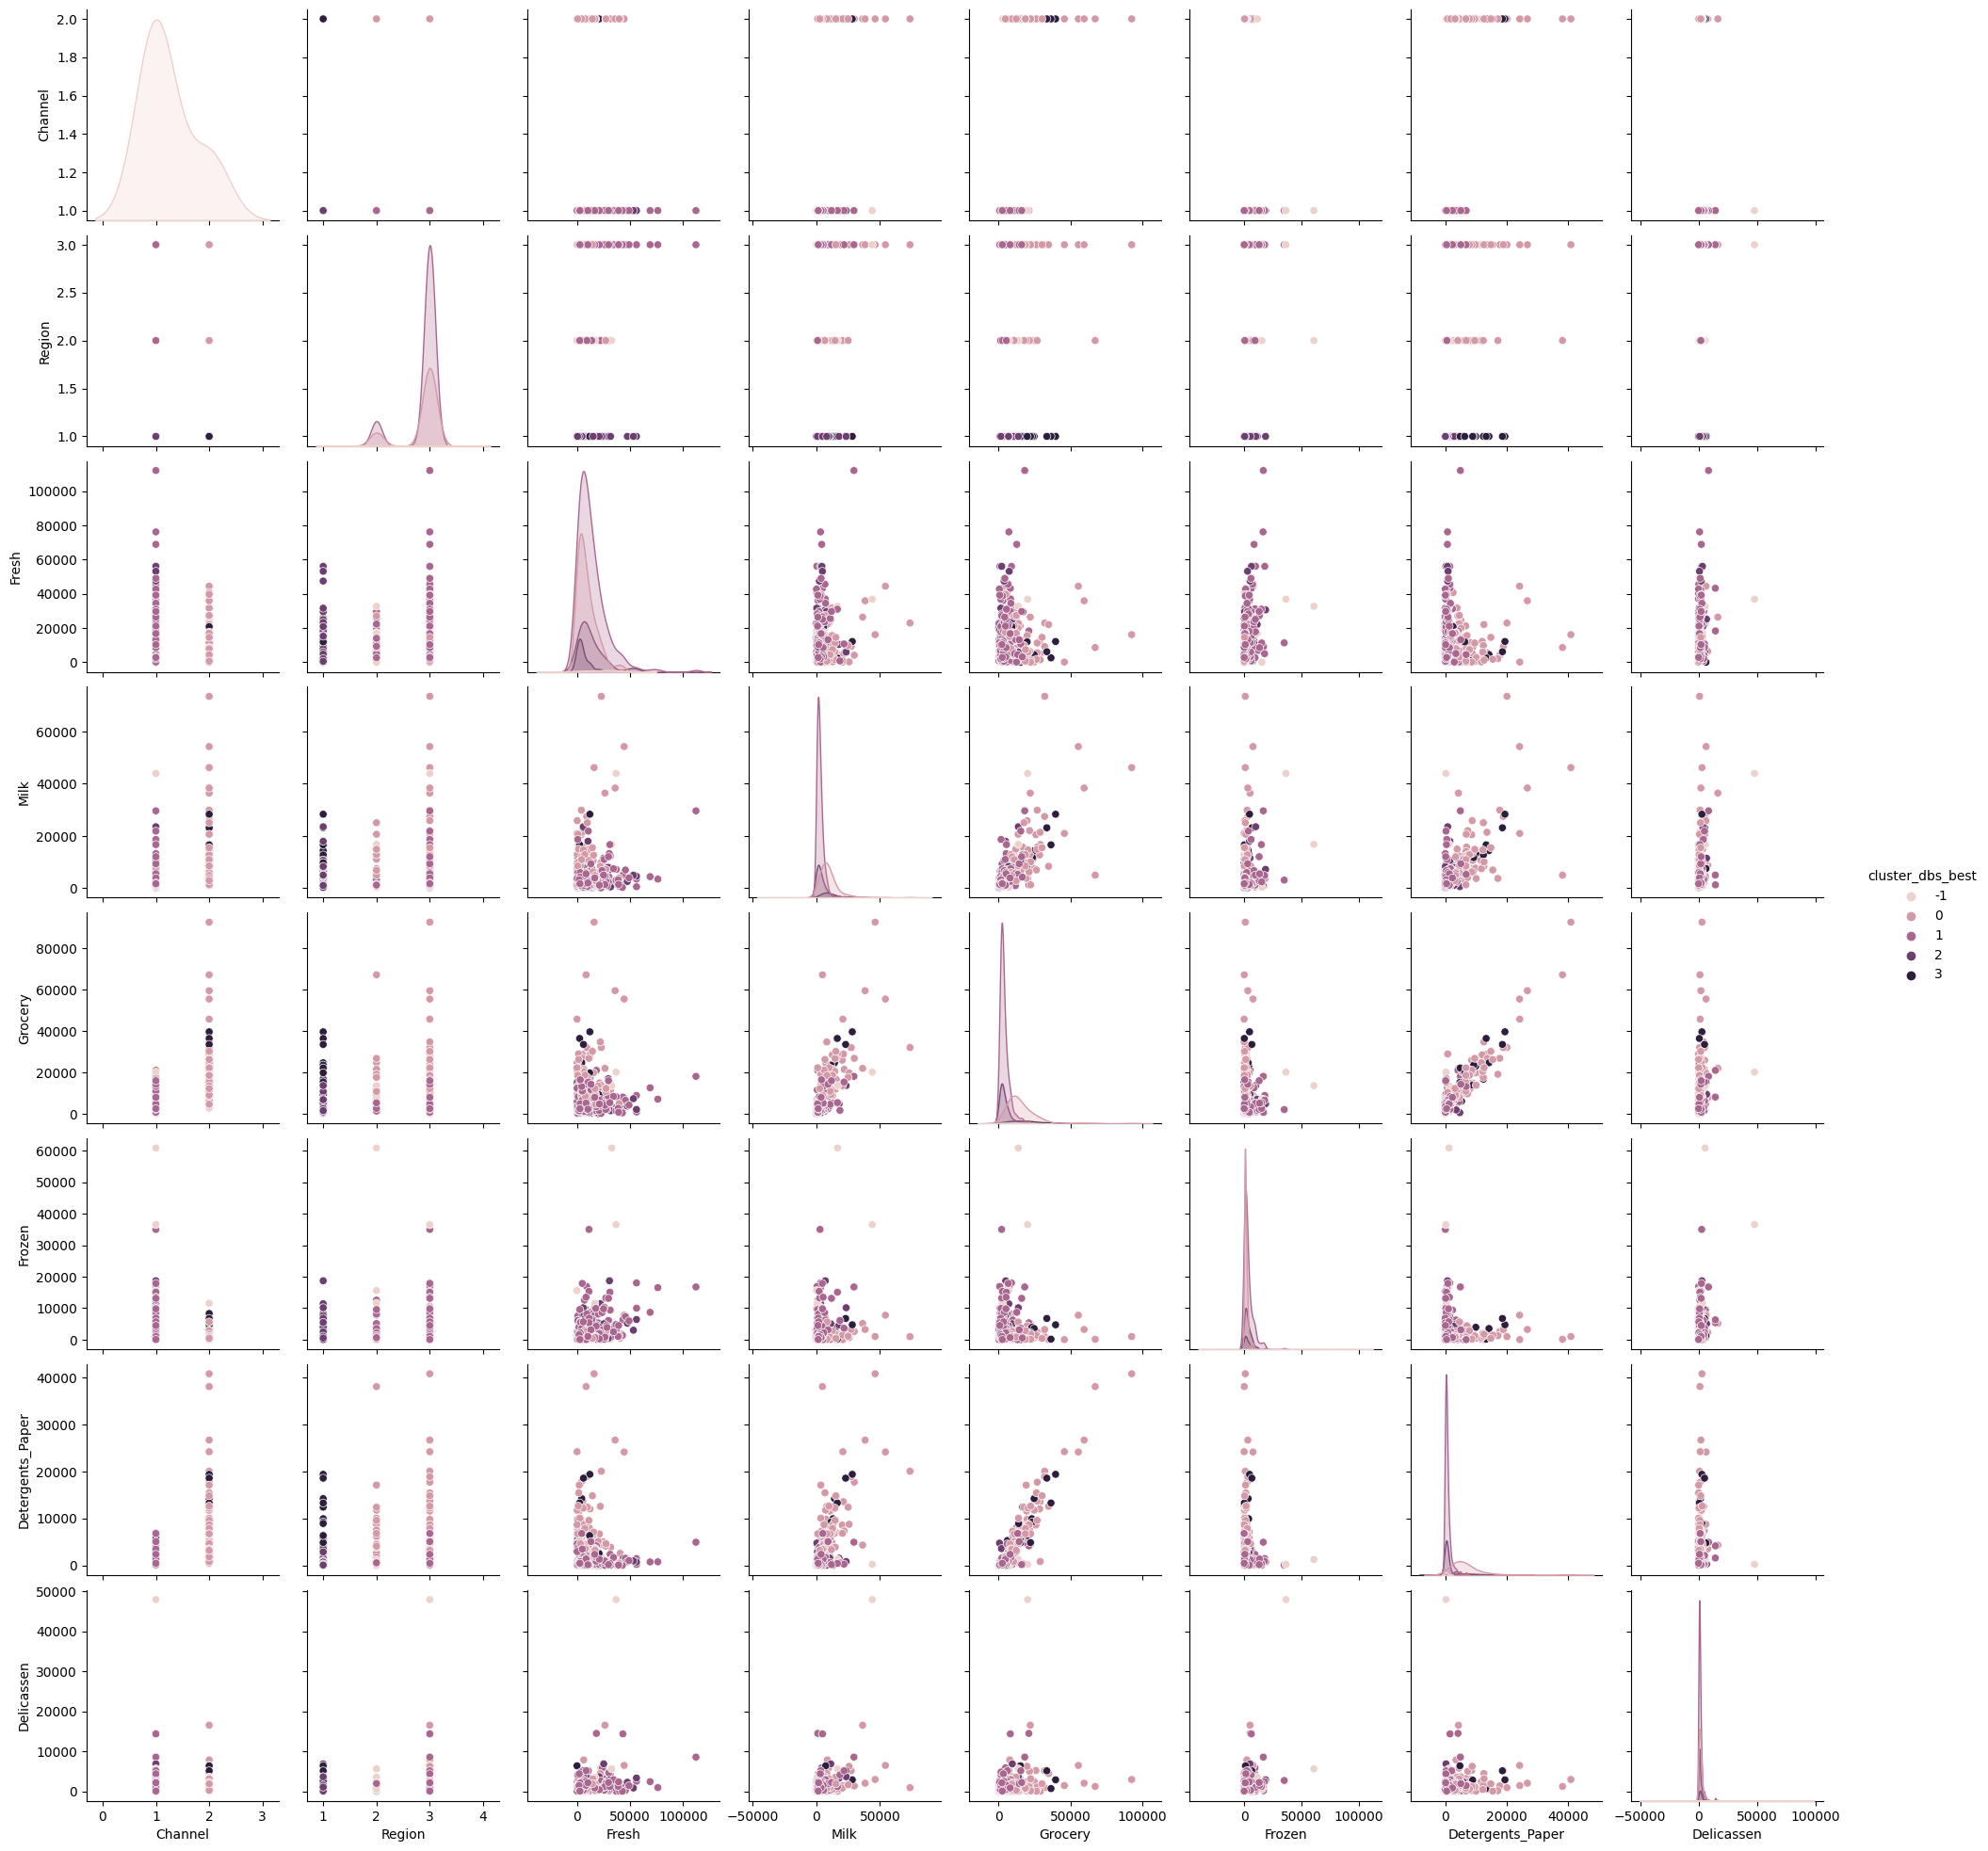

In [176]:
df_not_transformed["cluster_dbs_best"] = dbs.fit_predict(df)
sns.pairplot(df_not_transformed.drop(["cluster_km", "cluster_ac", "cluster_db_default"], axis=1), diag_kind="kde", hue="cluster_dbs_best")
plt.show()

Show the cluster sizes

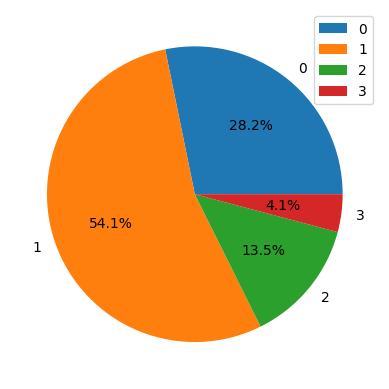

In [177]:
vals, freqs = np.unique(df_not_transformed["cluster_dbs_best"], return_counts=True)
plt.pie(x=freqs[1:], labels=vals[1:], autopct='%1.1f%%')    # 1.X where X is the num of decimals
plt.legend()
plt.show()

## Silhouette plots

Use the function `plot_silhouette` contained in the module `plot_silhouette_w_mean` (provided with the notebook) and from `sklearn.metrics` import the function `silhouette_samples` providing the silhouette score for each sample

`from plot_silhouette_w_mean import plot_silhouette  # python script provided separately`

Hint: use `help(plot_silhouette)` for the meaning of the parameters

Hint: for DBSCAN you should exclude the rows of noise

In [194]:
from plot_silhouette_w_mean import plot_silhouette  # python script provided separately


labels = df_not_transformed.columns[-4:]
labels = labels.delete(2)
labels

Index(['cluster_ac', 'cluster_km', 'cluster_dbs_best'], dtype='object')

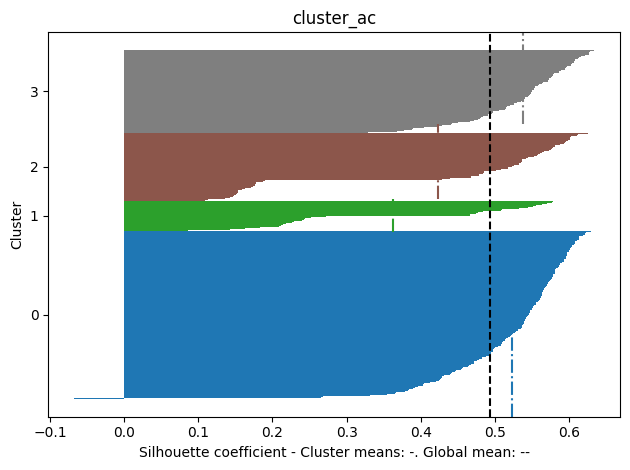

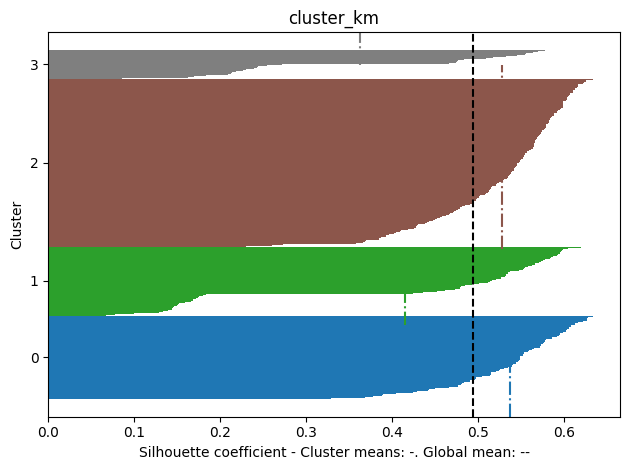

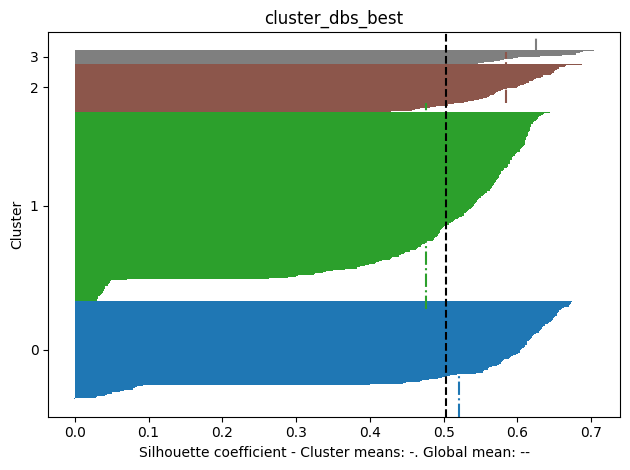

In [200]:
for l in labels:
    plt.title(l)
    plot_silhouette(
        silhouette_vals=silhouette_samples(df, df_not_transformed[l]),
        y=df_not_transformed[l]
    )

## Optional - Comparison with __boxplots__

For each of the clustering schemes show how the attribute values are distributed in the clusters

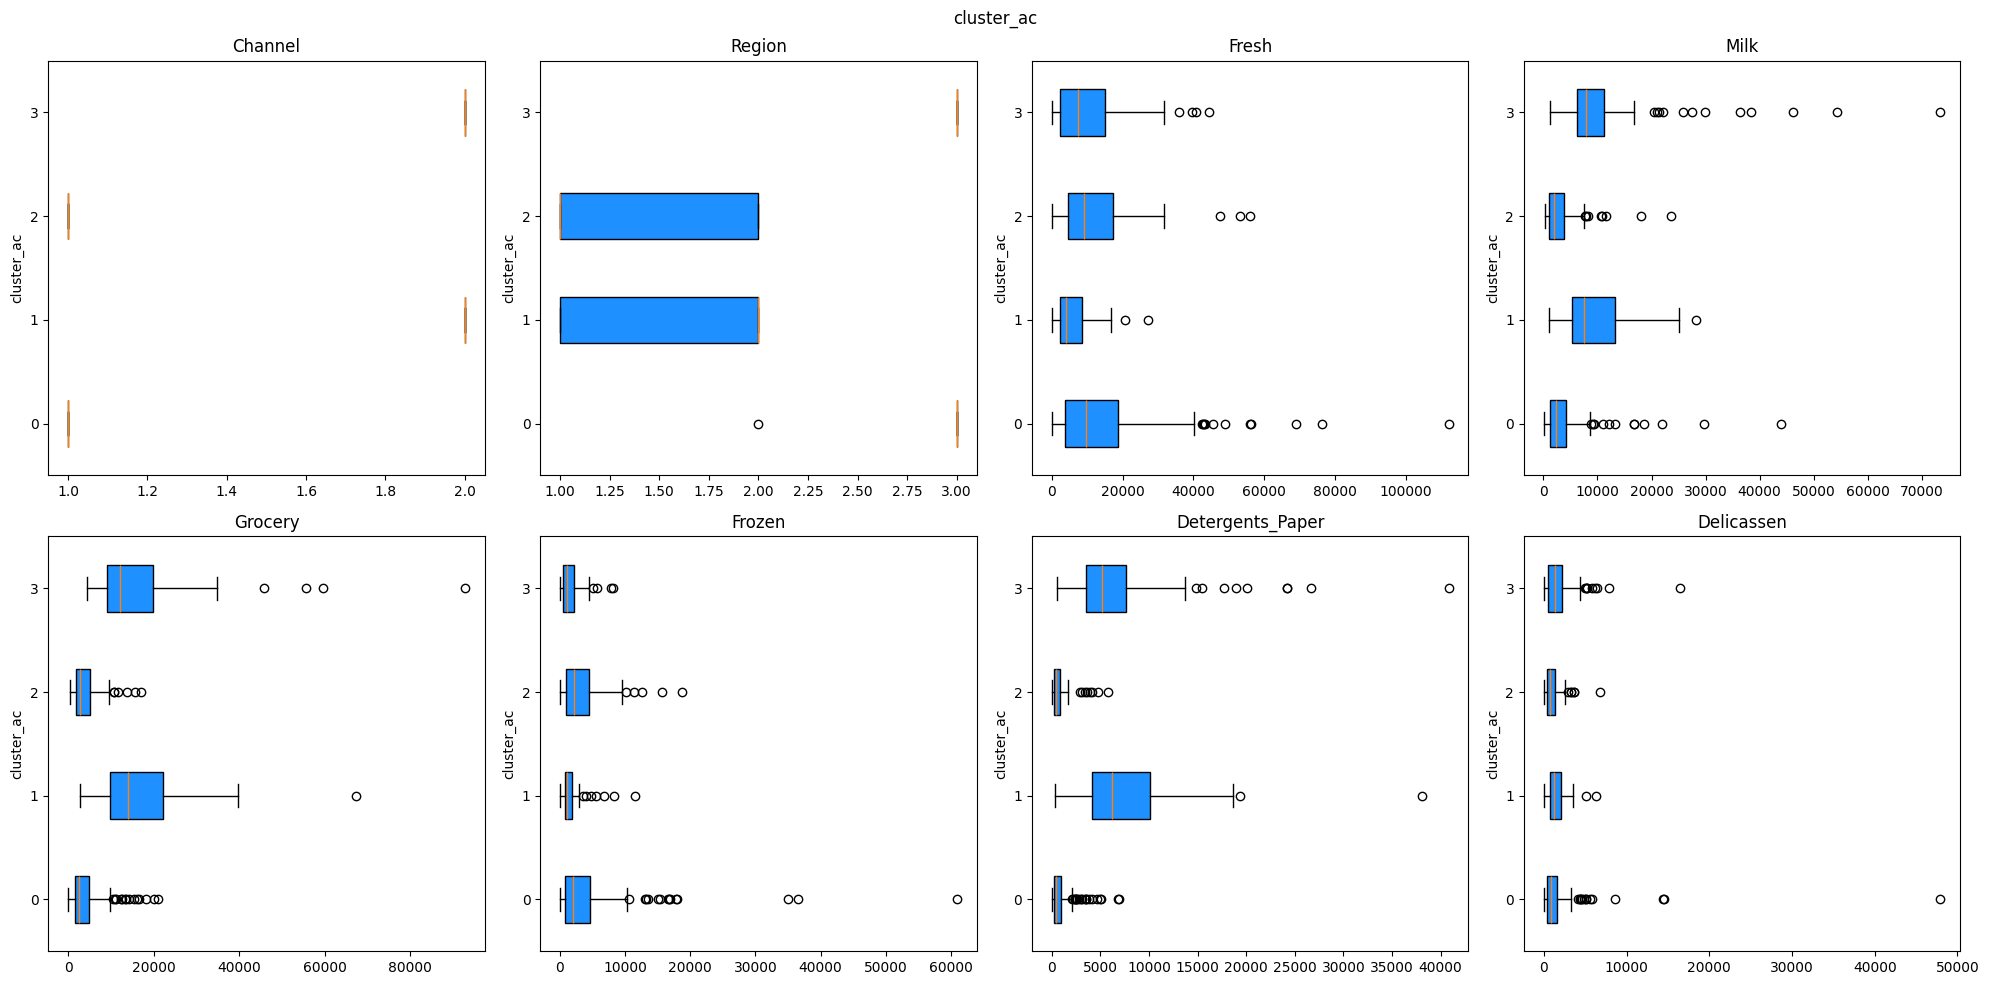

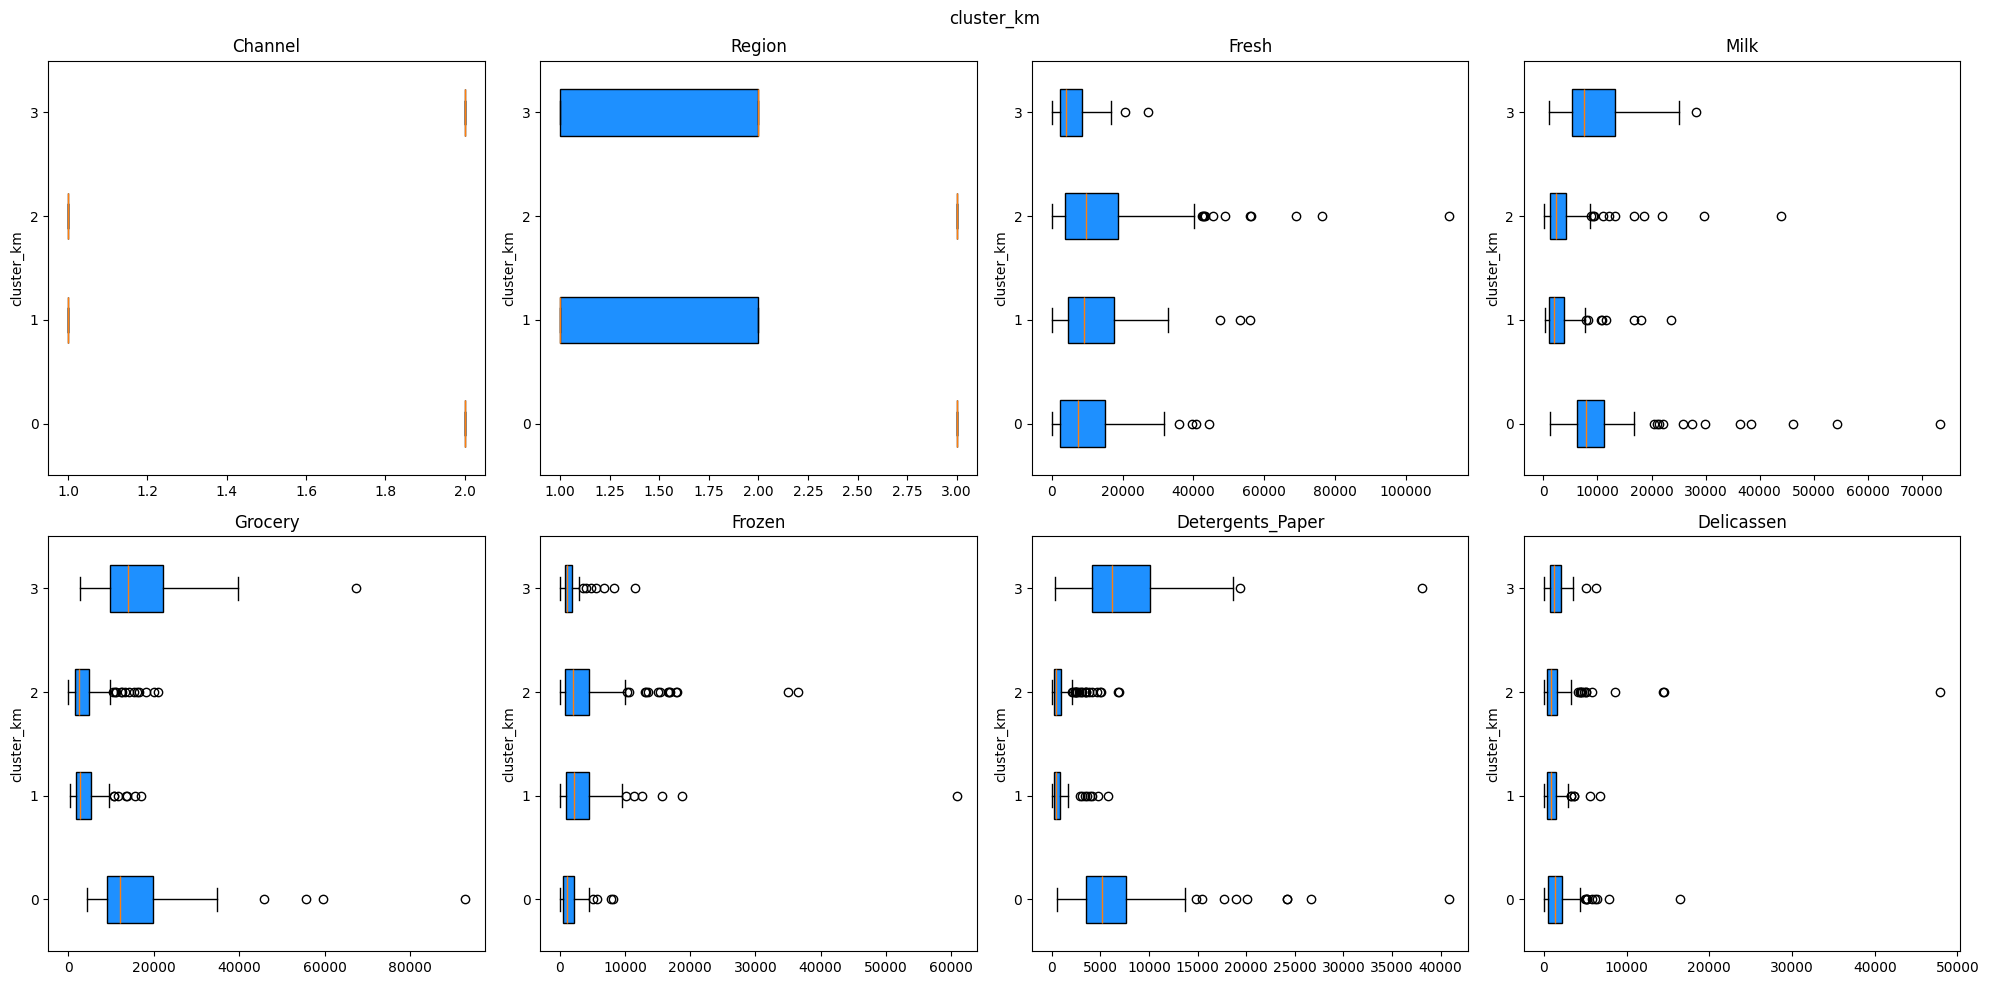

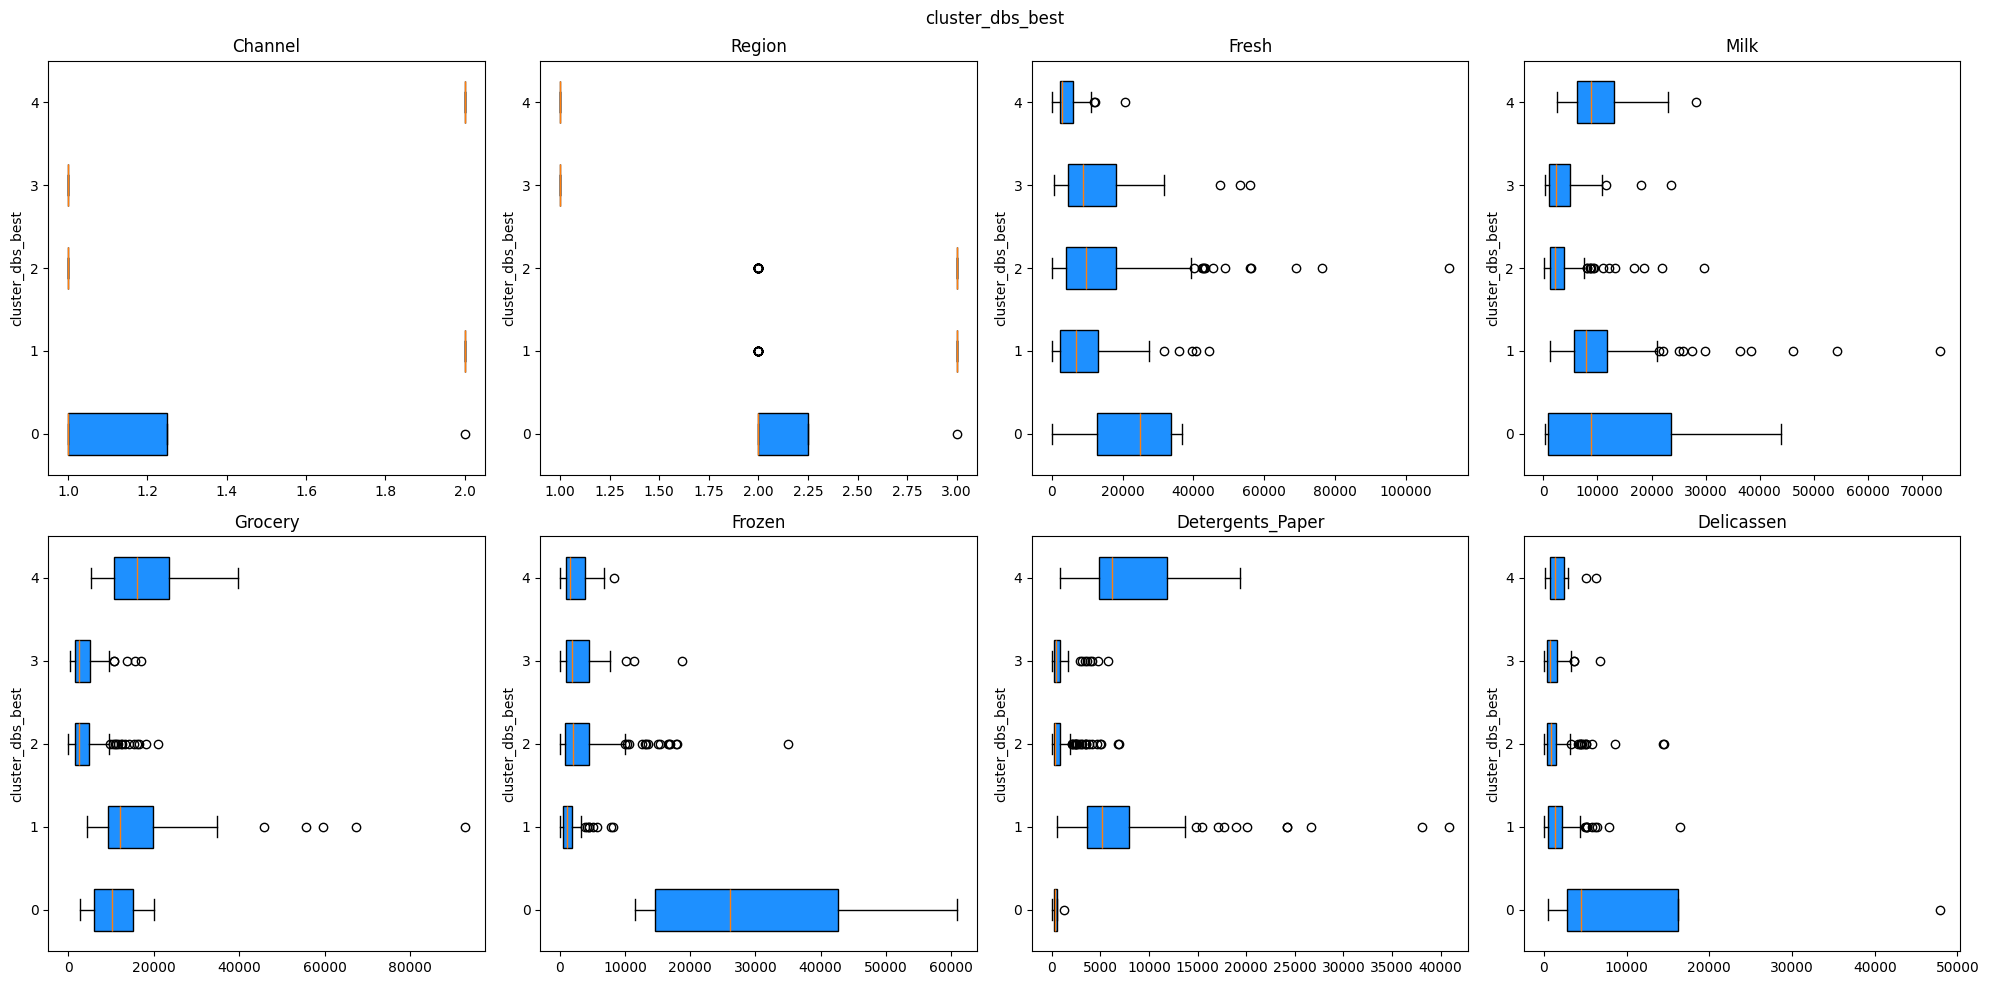

In [ ]:
attributes = df.columns

# Dynamically set the subplots (solo per esempio, non è necessario)
N = len(attributes)
K = 2
cols = int(np.ceil(N / K))

for l in labels:
    fig, axes = plt.subplots(K, cols, figsize=(5 * cols, 5 * K))
    fig.suptitle(l)
    for i in range(N):
        
        # Access the axis
        row = i // cols  
        col = i % cols   
        ax = axes[row, col] if K > 1 else axes[col]  # K=0 -> 1-D array
        
        # Alternativa:
        # axes = axes.flatten() 
        # e poi ciclare con zip(axes, attributes)
        
        # Plot
        n_cluster = len(np.unique(df_not_transformed[l]))
        attribute = attributes[i]
        ax.set_title(attribute)
        data = df_not_transformed.groupby(l)[attribute].apply(list)
        
        # bp useful only to set colors
        bp = ax.boxplot(
            data, 
            vert=False, 
            labels=[*range(n_cluster)], 
            patch_artist=True
        )
        for box in bp['boxes'] : box.set_facecolor('dodgerblue')
        
        ax.set_ylabel(l)
        
        
    plt.tight_layout()
    plt.show()
    

## Control questions
1. Repeat the experiments without the data transformations and comment the result
1. Repeat the final fittings with the numbers of clusters immediately before and after the chosen values and comment the results